# 08 — Model Training

**Author:** Florian Klaver

**Prerequisites:**
- Notebook 07 produced `data/training_samples_fusion.csv` (S2 + GRD events)
- Notebook 07 produced `data/training_samples_fusion_coh.csv` (+ InSAR coherence)

---

## Experiment design

Feature sets are derived from the permutation importance analysis (Section 2 below).

| Group | Dataset | Configs |
|---|---|---|
| **A** | `SAMPLES_FUSION_CSV` — all events with S1 GRD coverage | S2-only, GRD-only, S2+GRD |
| **B** | `SAMPLES_FUSION_COH_CSV` — coherence-eligible subset | Coh-only, CohJumps-only, S2+CohJumps, S2+Coh, Full-fusion | 

<br>

| Config | Feature set | n | Group |
|---|---|---|---|
| **S2-only** | ndii_diff, gndvi_diff, ndii_after, swir_after, evi_diff, green_after, swir_diff | 7 | A |
| **GRD-only** | vv_after, vh_after, cr_diff, vh_diff | 4 | A |
| **S2+GRD** | S2-only + GRD-only | 11 | A |
| **Coh-only** | coh_vv, coh_vh, coh_vv_jump, coh_vh_jump | 4 | B |
| **CohJumps-only** | coh_vv_jump, coh_vh_jump | 2 | B |
| **S2+CohJumps** | S2-only + CohJumps-only | 9 | B |
| **S2+Coh** | S2-only + Coh-only | 11 | B |
| **Full-fusion** | S2-only + GRD-only + Coh-only | 15 | B |

Each group has its own `GroupShuffleSplit(random_state=42, group=match_id)`.
Within-group comparisons are valid; cross-group F1 scores reflect different event populations.

---
## 1. Setup & Load Data

In [41]:
import sys
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath('..'))
from src.evaluation import (
    FEATURE_NAMES, prepare_data, evaluate_model,
    train_tuned_svm, train_tuned_rf, train_tuned_lgbm,
    find_optimal_threshold,
)
from src.config import *

os.makedirs(MODELS_DIR, exist_ok=True)

# Path to image fodler for report
IMG_DIR = DOCS_DIR

# Feature constants used by the feature selection analysis (Section 2 below)
SAR_FEATURES = ['vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']
COH_FEATURES = ['coh_before_vv', 'coh_before_vh', 'coh_after_vv', 'coh_after_vh', 'coh_vv_jump', 'coh_vh_jump']

# Group A: all events with S1 GRD coverage (S2 + GRD feature columns available)
fusion_df = pd.read_csv(SAMPLES_FUSION_CSV)
print(f'Group A (fusion): {len(fusion_df)} rows, {fusion_df["match_id"].nunique()} events')
print(f'Class balance:    {fusion_df["label"].value_counts().to_dict()}')

# Group B: events with valid InSAR coherence (coherence features non-NaN)
coh_raw = pd.read_csv(SAMPLES_FUSION_COH_CSV)
coh_df  = coh_raw.dropna(subset=COH_FEATURES).copy()
print(f'\nGroup B (coh):    {len(coh_df)} rows, {coh_df["match_id"].nunique()} events')
print(f'Class balance:    {coh_df["label"].value_counts().to_dict()}')

Group A (fusion): 33368 rows, 63 events
Class balance:    {1: 18077, 0: 15291}

Group B (coh):    15311 rows, 24 events
Class balance:    {1: 7694, 0: 7617}


---
## 2. Train/Test Splits

Two separate group-aware train/test splits — one per dataset group:

- **Group A:** `training_samples_fusion.csv` — all 63 events with S1 GRD coverage.
  Used for S2-only, GRD-only, and S2+GRD configs.
- **Group B:** `training_samples_fusion_coh.csv` — coherence-eligible subset (~33 events).
  Used for Coh-only, CohJumps-only, S2+CohJumps, S2+Coh, and Full-fusion configs.

Both splits use `GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42, group=match_id)`.
A comprehensive feature superset is passed to `prepare_data` for splitting purposes; training cells
then slice the per-config feature subset from the returned DataFrames.
Cross-group F1 comparisons are not meaningful — different event populations and test sets.

In [42]:
# Feature supersets for each group — splits performed here; training cells slice per-config.
# _GROUP_A_FEATS is the full 26-feature S2+GRD superset so training cells can slice any
# feature that comes out of the Analysis A selection below.
_GROUP_A_FEATS = [
    # 20 S2 optical features
    'ndvi_diff',  'evi_diff',  'savi_diff',  'gndvi_diff',  'ndii_diff',
    'ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after',
    'blue_diff',  'green_diff', 'red_diff',  'nir_diff',    'swir_diff',
    'blue_after', 'green_after','red_after', 'nir_after',   'swir_after',
    # 6 GRD SAR features
    'vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff',
]
_GROUP_B_FEATS = _GROUP_A_FEATS + ['coh_before_vv', 'coh_before_vh', 'coh_after_vv',
                                    'coh_after_vh', 'coh_vv_jump', 'coh_vh_jump']

X_train_A, y_train_A, groups_train_A, X_test_A, y_test_A = prepare_data(
    fusion_df, _GROUP_A_FEATS, random_state=42
)
print(f'Group A — Train: {len(X_train_A)} samples ({groups_train_A.nunique()} events), '
      f'Test: {len(X_test_A)} samples ({fusion_df.loc[X_test_A.index, "match_id"].nunique()} events)')

X_train_B, y_train_B, groups_train_B, X_test_B, y_test_B = prepare_data(
    coh_df, _GROUP_B_FEATS, random_state=42
)
print(f'Group B — Train: {len(X_train_B)} samples ({groups_train_B.nunique()} events), '
      f'Test: {len(X_test_B)} samples ({coh_df.loc[X_test_B.index, "match_id"].nunique()} events)')

Training: 24945 samples (50 matches)
Testing:  8423 samples (13 matches)
Group A — Train: 24945 samples (50 events), Test: 8423 samples (13 events)
Training: 12023 samples (19 matches)
Testing:  3288 samples (5 matches)
Group B — Train: 12023 samples (19 events), Test: 3288 samples (5 events)


---
## Feature Selection and Configuration Design

Feature selection is performed exclusively on the **training split** to prevent test-set leakage. The coherence-eligible subset is used because it is the only split containing all 30 features (20 S2 optical + 6 GRD backscatter + 4 InSAR coherence). The feature-selection train/test split uses the same `GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42, group=match_id)` as every other split in this notebook.

Three complementary methods are applied and then combined into a single decision table:

1. **Pearson correlation analysis** — identifies linearly redundant feature pairs within and across modalities. Pairs with |r| > 0.85 are candidates for pruning; of a correlated pair the one with lower permutation importance is marked REDUNDANT.

2. **Mean Decrease Impurity (MDI)** — ranks features by their average contribution to decision node purity inside a preliminary `RandomForestClassifier(n_estimators=200, random_state=42)` trained on the full 30-feature training set. Fast and model-integrated, but can over-rate highly correlated or high-cardinality features.

3. **Permutation importance** — each feature is shuffled 20 times on a held-out `GroupKFold` validation fold (not the test set) and the mean F1 decrease is recorded. Model-agnostic and directly tied to generalisation performance. Features with mean ≤ 0 are DROP candidates.

The resulting lean feature sets (`S2_BEST`, `GRD_BEST`) are used to define all experiment configurations at the end of this section, and should be compared against the hardcoded `S2_LEAN_FEATURES` / `SAR_FEATURES` constants defined in the Setup cell above.

──────────────────────────────────────────────────────────────────────
STEP 2 — Pearson Correlation (training set only)
──────────────────────────────────────────────────────────────────────
Feature-selection training set: 12023 samples, 19 events (coherence subset)


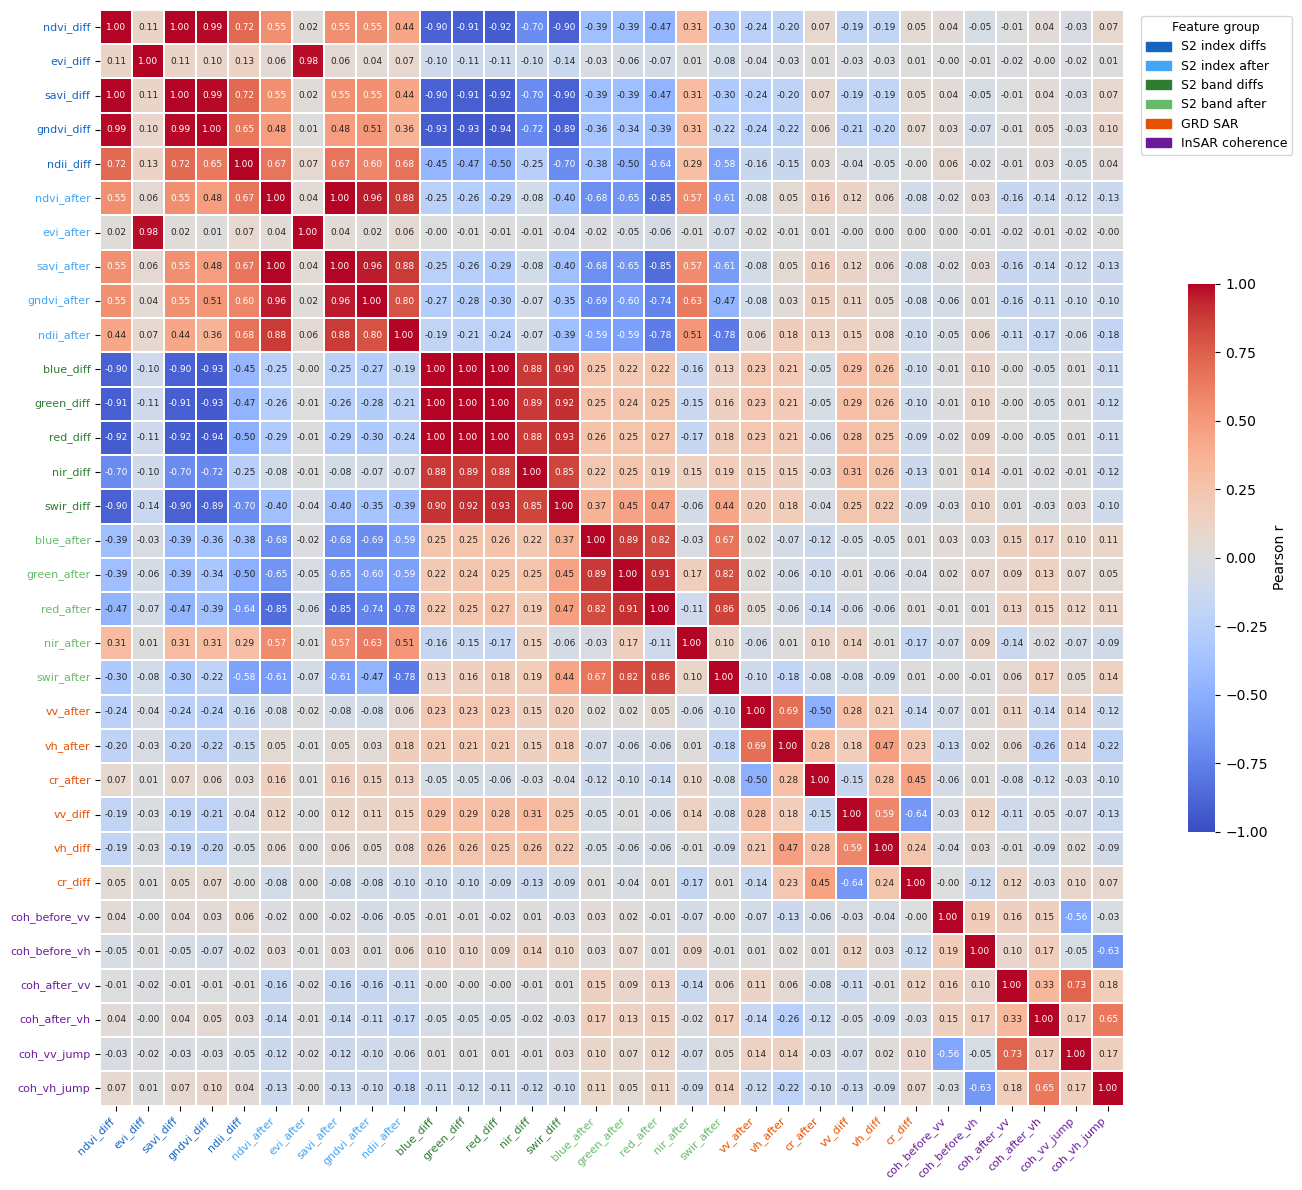

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\docs\images\pearson_correlation.png

Highly correlated feature pairs (|r| > 0.85, sorted by |r| desc):
  savi_diff              ↔  ndvi_diff               r = +1.000  [S2 index diffs × S2 index diffs]
  savi_after             ↔  ndvi_after              r = +1.000  [S2 index after × S2 index after]
  red_diff               ↔  green_diff              r = +0.999  [S2 band diffs × S2 band diffs]
  green_diff             ↔  blue_diff               r = +0.999  [S2 band diffs × S2 band diffs]
  red_diff               ↔  blue_diff               r = +0.997  [S2 band diffs × S2 band diffs]
  gndvi_diff             ↔  savi_diff               r = +0.989  [S2 index diffs × S2 index diffs]
  gndvi_diff             ↔  ndvi_diff               r = +0.989  [S2 index diffs × S2 index diffs]
  evi_after              ↔  evi_diff                r = +0.980  [S2 index after × S2 index diffs]
  gndvi_after            ↔  savi_after              r =

In [43]:
import seaborn as sns
import matplotlib.patches as mpatches

# ── STEP 2 — Pearson Correlation Matrix ──────────────────────────────────────
# Training split only; never touches the test set.

print('─' * 70)
print('STEP 2 — Pearson Correlation (training set only)')
print('─' * 70)

# ── Feature group definitions (order sets heatmap layout) ───────────────────
FS_S2_INDEX_DIFF  = ['ndvi_diff',  'evi_diff',  'savi_diff',  'gndvi_diff',  'ndii_diff']
FS_S2_INDEX_AFTER = ['ndvi_after', 'evi_after', 'savi_after', 'gndvi_after', 'ndii_after']
FS_S2_BAND_DIFF   = ['blue_diff',  'green_diff', 'red_diff',  'nir_diff',    'swir_diff']
FS_S2_BAND_AFTER  = ['blue_after', 'green_after','red_after', 'nir_after',   'swir_after']
FS_ALL_S2  = FS_S2_INDEX_DIFF + FS_S2_INDEX_AFTER + FS_S2_BAND_DIFF + FS_S2_BAND_AFTER
FS_ALL_30  = FS_ALL_S2 + SAR_FEATURES + COH_FEATURES

GROUP_DEFS = [
    ('S2 index diffs',  FS_S2_INDEX_DIFF,  '#1565C0'),
    ('S2 index after',  FS_S2_INDEX_AFTER, '#42A5F5'),
    ('S2 band diffs',   FS_S2_BAND_DIFF,   '#2E7D32'),
    ('S2 band after',   FS_S2_BAND_AFTER,  '#66BB6A'),
    ('GRD SAR',         SAR_FEATURES,      '#E65100'),
    ('InSAR coherence', COH_FEATURES,      '#6A1B9A'),
]
_feat_color = {f: c for _, feats, c in GROUP_DEFS for f in feats}
_feat_group = {f: n for n, feats, _ in GROUP_DEFS for f in feats}

# Consistent bar-chart colors (blue S2 / orange GRD / purple Coh)
FS_COLOR_S2  = '#2196F3'
FS_COLOR_GRD = '#FF6D00'
FS_COLOR_COH = '#7B1FA2'

def _fs_bar_color(feat):
    if feat in COH_FEATURES: return FS_COLOR_COH
    if feat in SAR_FEATURES:  return FS_COLOR_GRD
    return FS_COLOR_S2

FS_LEGEND = [
    mpatches.Patch(color=FS_COLOR_S2,  label='S2 optical'),
    mpatches.Patch(color=FS_COLOR_GRD, label='GRD SAR'),
    mpatches.Patch(color=FS_COLOR_COH, label='InSAR coherence'),
]

# ── Feature-selection training split (same GSS params as every other split) ─
from sklearn.model_selection import GroupShuffleSplit as _GSS
_fs_base = coh_df[FS_ALL_30 + ['match_id', 'label']].dropna(subset=FS_ALL_30)
_gss_fs  = _GSS(n_splits=1, test_size=0.2, random_state=42)
_tr_idx, _ = next(_gss_fs.split(_fs_base[FS_ALL_30], _fs_base['label'], _fs_base['match_id']))
fs_train_df     = _fs_base.iloc[_tr_idx].copy()
fs_groups_train = fs_train_df['match_id']
print(f'Feature-selection training set: {len(fs_train_df)} samples, '
      f'{fs_groups_train.nunique()} events (coherence subset)')

# Output directory for all feature-selection plots
FS_DIR = RESULTS_DIR / 'feature_selection'
os.makedirs(FS_DIR, exist_ok=True)

# ── Pearson correlation on training features ─────────────────────────────────
corr_matrix = fs_train_df[FS_ALL_30].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix.loc[FS_ALL_30, FS_ALL_30],
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    annot_kws={'size': 6.5}, linewidths=0.2, linecolor='white',
    cbar_kws={'shrink': 0.5, 'label': 'Pearson r'},
    ax=ax,
)
#ax.set_title('Pearson Correlation — 30 features (coherence training set only)', fontsize=13)

# Colour tick labels by feature group
for tick in ax.get_yticklabels():
    tick.set_color(_feat_color.get(tick.get_text(), 'black'))
    tick.set_fontsize(8)
for tick in ax.get_xticklabels():
    tick.set_color(_feat_color.get(tick.get_text(), 'black'))
    tick.set_fontsize(8)
plt.xticks(rotation=45, ha='right')

_group_patches = [mpatches.Patch(color=c, label=n) for n, _, c in GROUP_DEFS]
ax.legend(handles=_group_patches, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, title='Feature group', title_fontsize=9)
plt.tight_layout()
fig.savefig(IMG_DIR / 'pearson_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {IMG_DIR / "pearson_correlation.png"}')

# ── High-correlation pairs ───────────────────────────────────────────────────
print('\nHighly correlated feature pairs (|r| > 0.85, sorted by |r| desc):')
_high = []
for _i, _f1 in enumerate(FS_ALL_30):
    for _j, _f2 in enumerate(FS_ALL_30):
        if _j >= _i:
            continue
        _r = corr_matrix.loc[_f1, _f2]
        if abs(_r) > 0.85:
            _high.append((abs(_r), _r, _f1, _f2))
_high.sort(reverse=True)

if _high:
    for _abs_r, _r, _f1, _f2 in _high:
        print(f'  {_f1:<22} ↔  {_f2:<22}  r = {_r:+.3f}'
              f'  [{_feat_group[_f1]} × {_feat_group[_f2]}]')
else:
    print('  None — no feature pairs exceed |r| = 0.85')

# Per-group redundancy summary
print()
for _gname, _gfeats, _ in GROUP_DEFS:
    _within = sum(1 for _, _, a, b in _high
                  if _feat_group.get(a) == _gname and _feat_group.get(b) == _gname)
    _cross  = sum(1 for _, _, a, b in _high
                  if (_feat_group.get(a) == _gname) != (_feat_group.get(b) == _gname))
    _parts = []
    if _within: _parts.append(f'{_within} within-group redundant pair(s)')
    if _cross:  _parts.append(f'{_cross} cross-group pair(s)')
    _status = ', '.join(_parts) if _parts else 'no pairs above threshold'
    print(f'  {_gname:<22}: {_status}')

──────────────────────────────────────────────────────────────────────
STEP 3 — MDI Feature Importance  [not saved to models/]
──────────────────────────────────────────────────────────────────────

── Analysis A: S2 + GRD features (Group A, fusion_df) ──
Analysis A training set: 24945 samples, 50 events
Preliminary RF trained on 24945 samples (Analysis A, MDI only).

MDI ranking — S2 + GRD (Group A, N=24945):
   1. ndii_diff               MDI = 0.14677  [S2 index diffs]
   2. savi_diff               MDI = 0.10381  [S2 index diffs]
   3. evi_diff                MDI = 0.09726  [S2 index diffs]
   4. swir_after              MDI = 0.08789  [S2 band after]
   5. ndvi_diff               MDI = 0.08074  [S2 index diffs]
   6. evi_after               MDI = 0.07035  [S2 index after]
   7. ndii_after              MDI = 0.05307  [S2 index after]
   8. ndvi_after              MDI = 0.04398  [S2 index after]
   9. swir_diff               MDI = 0.03700  [S2 band diffs]
  10. savi_after              

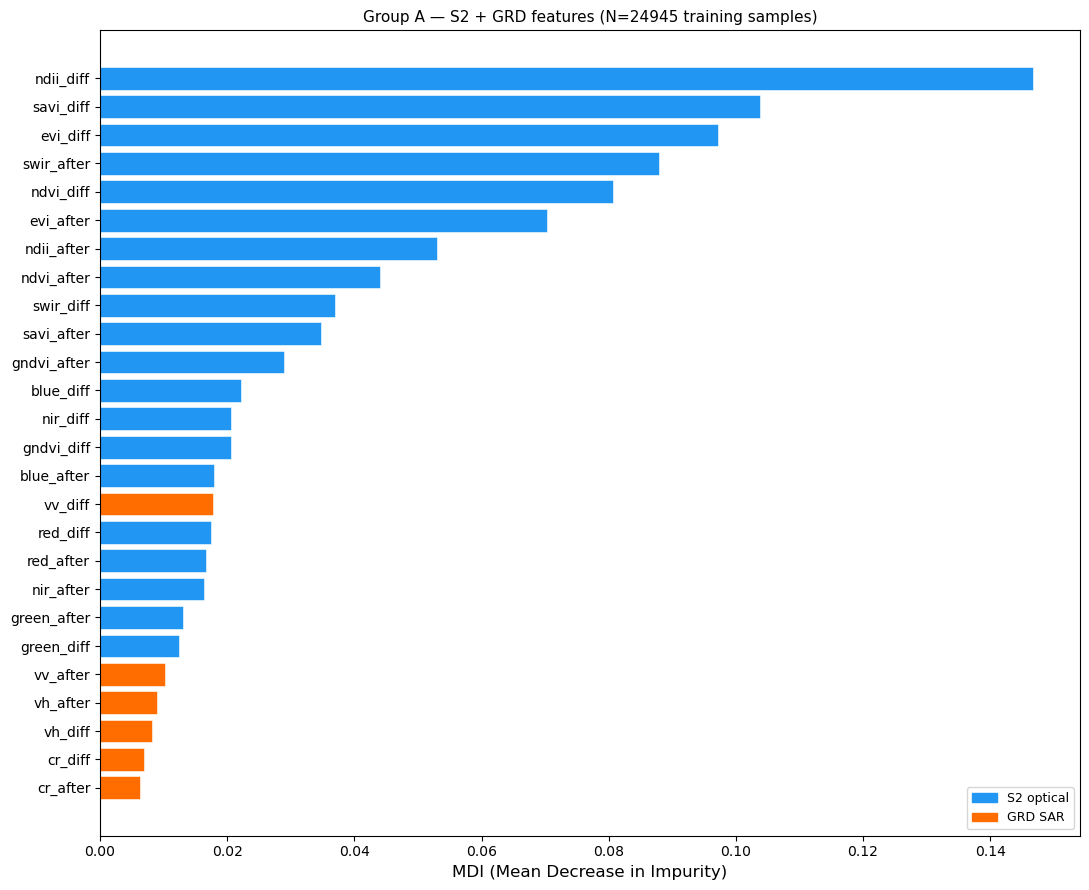

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\docs\images\mdi_importance.png

── Analysis B: Coherence features only (Group B, coh_df) ──
Analysis B training set: 12023 samples, 19 events
Preliminary RF trained on 12023 samples (Analysis B, MDI only).

MDI ranking — Coherence (Group B, N=12023):
   1. coh_vh_jump             MDI = 0.17281
   2. coh_vv_jump             MDI = 0.16993
   3. coh_before_vh           MDI = 0.16631
   4. coh_after_vh            MDI = 0.16502
   5. coh_after_vv            MDI = 0.16387
   6. coh_before_vv           MDI = 0.16206


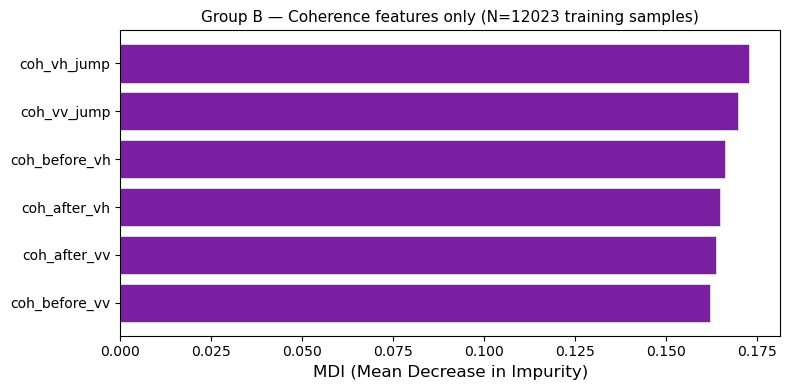

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\docs\images\mdi_importance_B.png


In [44]:
# ── STEP 3 — Preliminary RF for MDI ─────────────────────────────────────────
# Analysis A: S2 + GRD features on Group A (fusion_df, 26 features)
# Analysis B: Coherence features on Group B (coh_df training split, 4 features)
# FOR FEATURE SELECTION ONLY — these models are NOT saved to models/

print('─' * 70)
print('STEP 3 — MDI Feature Importance  [not saved to models/]')
print('─' * 70)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit as _GSS

FS_ALL_26 = FS_ALL_S2 + SAR_FEATURES  # 26 features: 20 S2 optical + 6 GRD SAR (no coherence)

# ── Analysis A: S2 + GRD on fusion_df (Group A) ─────────────────────────────
print('\n── Analysis A: S2 + GRD features (Group A, fusion_df) ──')
_fs_A_base = fusion_df[FS_ALL_26 + ['match_id', 'label']].dropna(subset=FS_ALL_26)
_gss_A = _GSS(n_splits=1, test_size=0.2, random_state=42)
_tr_idx_A, _ = next(_gss_A.split(_fs_A_base[FS_ALL_26], _fs_A_base['label'], _fs_A_base['match_id']))
fs_train_A  = _fs_A_base.iloc[_tr_idx_A].copy()
fs_groups_A = fs_train_A['match_id']
print(f'Analysis A training set: {len(fs_train_A)} samples, {fs_groups_A.nunique()} events')

X_fs_A = fs_train_A[FS_ALL_26]
y_fs_A = fs_train_A['label']

_rf_A = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
_rf_A.fit(X_fs_A, y_fs_A)
print(f'Preliminary RF trained on {len(X_fs_A)} samples (Analysis A, MDI only).')

mdi_A = pd.Series(_rf_A.feature_importances_, index=FS_ALL_26).sort_values(ascending=False)

print(f'\nMDI ranking — S2 + GRD (Group A, N={len(fs_train_A)}):')
for _rnk, (_feat, _val) in enumerate(mdi_A.items(), 1):
    print(f'  {_rnk:>2}. {_feat:<22}  MDI = {_val:.5f}  [{_feat_group.get(_feat, "")}]')

_mp_A = mdi_A.sort_values(ascending=True)
_legend_A = [
    mpatches.Patch(color=FS_COLOR_S2,  label='S2 optical'),
    mpatches.Patch(color=FS_COLOR_GRD, label='GRD SAR'),
]
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(_mp_A.index, _mp_A.values,
        color=[_fs_bar_color(f) for f in _mp_A.index],
        edgecolor='white', linewidth=0.4)
ax.set_xlabel('MDI (Mean Decrease in Impurity)', fontsize=12)
ax.set_title(f'Group A — S2 + GRD features (N={len(fs_train_A)} training samples)', fontsize=11)
ax.legend(handles=_legend_A, loc='lower right', fontsize=9)
plt.tight_layout()
fig.savefig(IMG_DIR / 'mdi_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {IMG_DIR / "mdi_importance.png"}')

# ── Analysis B: Coherence features on coh_df training split (Group B) ───────
print('\n── Analysis B: Coherence features only (Group B, coh_df) ──')
# fs_train_df and fs_groups_train are defined in the Pearson cell (Group B split)
X_fs_B = fs_train_df[COH_FEATURES]
y_fs_B = fs_train_df['label']
print(f'Analysis B training set: {len(X_fs_B)} samples, {fs_groups_train.nunique()} events')

_rf_B = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
_rf_B.fit(X_fs_B, y_fs_B)
print(f'Preliminary RF trained on {len(X_fs_B)} samples (Analysis B, MDI only).')

mdi_B = pd.Series(_rf_B.feature_importances_, index=COH_FEATURES).sort_values(ascending=False)

print(f'\nMDI ranking — Coherence (Group B, N={len(X_fs_B)}):')
for _rnk, (_feat, _val) in enumerate(mdi_B.items(), 1):
    print(f'  {_rnk:>2}. {_feat:<22}  MDI = {_val:.5f}')

_mp_B = mdi_B.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(_mp_B.index, _mp_B.values,
        color=FS_COLOR_COH, edgecolor='white', linewidth=0.4)
ax.set_xlabel('MDI (Mean Decrease in Impurity)', fontsize=12)
ax.set_title(f'Group B — Coherence features only (N={len(X_fs_B)} training samples)', fontsize=11)
plt.tight_layout()
fig.savefig(IMG_DIR / 'mdi_importance_B.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {IMG_DIR / "mdi_importance_B.png"}')

──────────────────────────────────────────────────────────────────────
STEP 4 — Permutation Importance  [held-out fold, NOT the test set]
──────────────────────────────────────────────────────────────────────

── Analysis A: S2 + GRD features (Group A) ──
Held-out fold A — train: 19961 samples, val: 4984 samples
Fold RF trained. Held-out F1: 0.9057
Computing permutation importance (n_repeats=20, scoring=f1)...

Permutation Importance — S2 + GRD (Group A, N=24945):
    feature      mean      std
  ndii_diff  0.031234 0.002000
 swir_after  0.008973 0.002169
  evi_after  0.005301 0.001287
  swir_diff  0.003225 0.001658
gndvi_after  0.002932 0.001048
   cr_after  0.000110 0.000610
  nir_after  0.000056 0.001163
green_after -0.000209 0.000520
 ndvi_after -0.000658 0.000848
 savi_after -0.000661 0.000988
    vh_diff -0.000763 0.000639
 ndii_after -0.000870 0.001548
  ndvi_diff -0.001788 0.000995
    cr_diff -0.002990 0.000961
    vv_diff -0.003297 0.000931
  red_after -0.004208 0.000707
 gnd

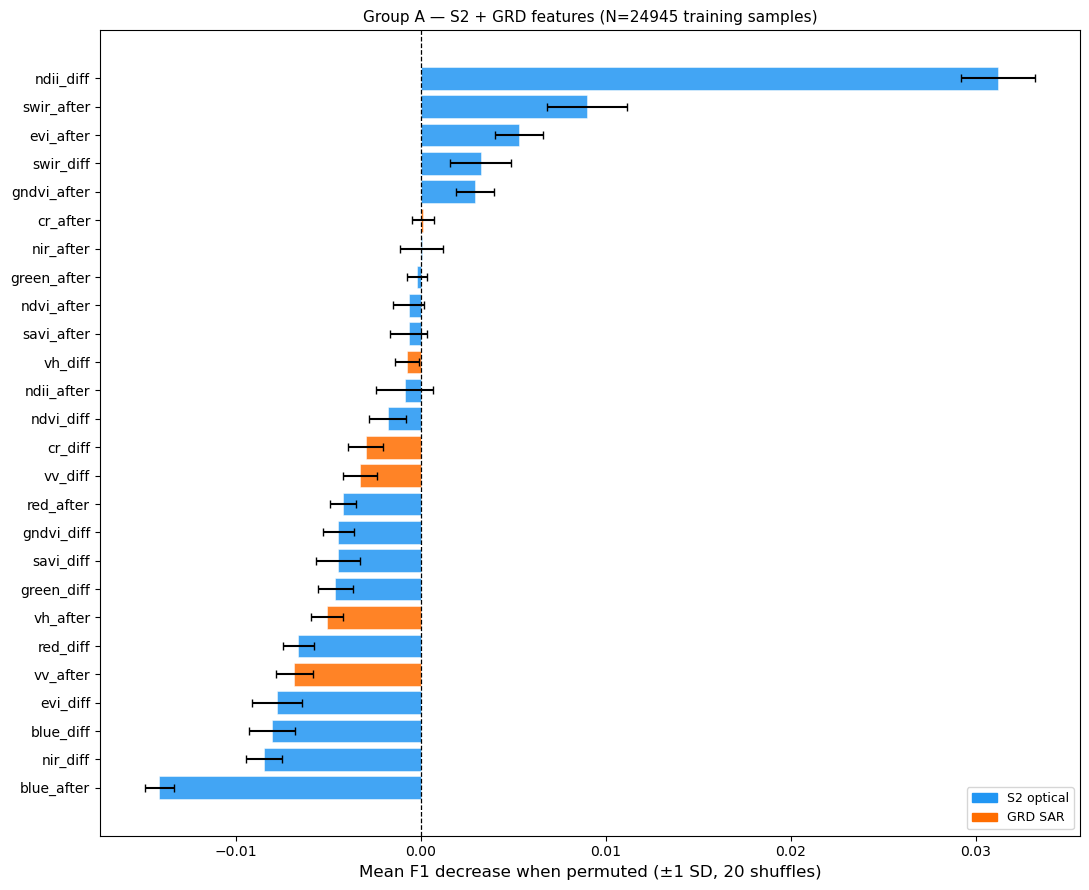

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\docs\images\perm_importance.png

── Analysis B: Coherence features only (Group B) ──
Held-out fold B — train: 9609 samples, val: 2414 samples
Fold RF trained. Held-out F1: 0.4675
Computing permutation importance (n_repeats=20, scoring=f1)...

Permutation Importance — Coherence (Group B, N=12023):
      feature      mean      std
coh_before_vh  0.015338 0.007050
 coh_after_vv  0.007486 0.008432
  coh_vv_jump -0.001690 0.008469
  coh_vh_jump -0.002809 0.006273
coh_before_vv -0.004836 0.006186
 coh_after_vh -0.015219 0.005956


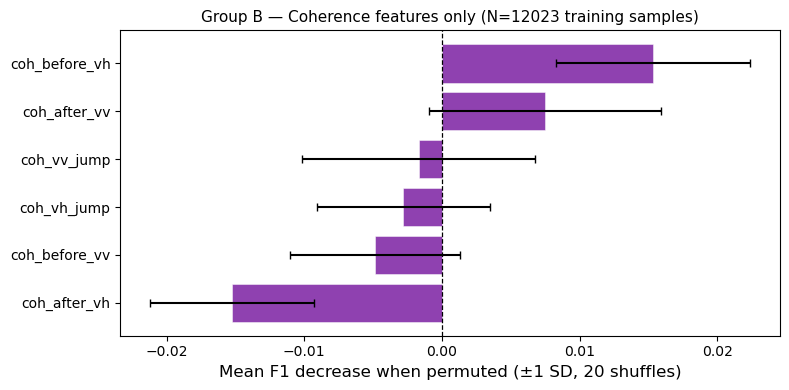

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\docs\images\perm_importance_B.png


In [45]:
# ── STEP 4 — Permutation Importance (held-out GroupKFold fold) ───────────────
# Analysis A: S2 + GRD features on Group A training split (fusion_df)
# Analysis B: Coherence features on Group B training split (coh_df)
# Both use the last fold of 5-fold GroupKFold as the held-out evaluation set.
# This is NOT the main test set.

print('─' * 70)
print('STEP 4 — Permutation Importance  [held-out fold, NOT the test set]')
print('─' * 70)

from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance as _compute_perm_imp
from sklearn.metrics import f1_score as _f1_score
from sklearn.ensemble import RandomForestClassifier

# ── Analysis A: S2 + GRD on Group A ─────────────────────────────────────────
print('\n── Analysis A: S2 + GRD features (Group A) ──')
_gkf_A = GroupKFold(n_splits=5)
_folds_A = list(_gkf_A.split(X_fs_A, y_fs_A, fs_groups_A))
_perm_tr_A, _perm_va_A = _folds_A[-1]

X_perm_tr_A = X_fs_A.iloc[_perm_tr_A]
y_perm_tr_A = y_fs_A.iloc[_perm_tr_A]
X_perm_va_A = X_fs_A.iloc[_perm_va_A]
y_perm_va_A = y_fs_A.iloc[_perm_va_A]
print(f'Held-out fold A — train: {len(X_perm_tr_A)} samples, val: {len(X_perm_va_A)} samples')

_rf_perm_A = RandomForestClassifier(n_estimators=200, max_depth=None,
                                    random_state=42, n_jobs=-1)
_rf_perm_A.fit(X_perm_tr_A, y_perm_tr_A)
print(f'Fold RF trained. Held-out F1: '
      f'{_f1_score(y_perm_va_A, _rf_perm_A.predict(X_perm_va_A)):.4f}')

print('Computing permutation importance (n_repeats=20, scoring=f1)...')
_perm_result_A = _compute_perm_imp(
    _rf_perm_A, X_perm_va_A, y_perm_va_A,
    n_repeats=20, scoring='f1', random_state=42, n_jobs=-1,
)

perm_A = pd.DataFrame({
    'feature': FS_ALL_26,
    'mean':    _perm_result_A.importances_mean,
    'std':     _perm_result_A.importances_std,
}).sort_values('mean', ascending=False).reset_index(drop=True)

print(f'\nPermutation Importance — S2 + GRD (Group A, N={len(X_fs_A)}):')
print(perm_A.to_string(index=False))

_zero_A = perm_A[perm_A['mean'] <= 0.0]['feature'].tolist()
print(f'\nDROP candidates — mean ≤ 0 ({len(_zero_A)} features): {_zero_A}')

_pp_A = perm_A.sort_values('mean', ascending=True)
_legend_A = [
    mpatches.Patch(color=FS_COLOR_S2,  label='S2 optical'),
    mpatches.Patch(color=FS_COLOR_GRD, label='GRD SAR'),
]
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(_pp_A['feature'], _pp_A['mean'], xerr=_pp_A['std'],
        color=[_fs_bar_color(f) for f in _pp_A['feature']],
        alpha=0.85, capsize=3, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', lw=0.9, linestyle='--')
ax.set_xlabel('Mean F1 decrease when permuted (±1 SD, 20 shuffles)', fontsize=12)
ax.set_title(f'Group A — S2 + GRD features (N={len(X_fs_A)} training samples)', fontsize=11)
ax.legend(handles=_legend_A, loc='lower right', fontsize=9)
plt.tight_layout()
fig.savefig(IMG_DIR / 'perm_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {IMG_DIR / "perm_importance.png"}')

# ── Analysis B: Coherence features on Group B ───────────────────────────────
print('\n── Analysis B: Coherence features only (Group B) ──')
_gkf_B = GroupKFold(n_splits=5)
_folds_B = list(_gkf_B.split(X_fs_B, y_fs_B, fs_groups_train))
_perm_tr_B, _perm_va_B = _folds_B[-1]

X_perm_tr_B = X_fs_B.iloc[_perm_tr_B]
y_perm_tr_B = y_fs_B.iloc[_perm_tr_B]
X_perm_va_B = X_fs_B.iloc[_perm_va_B]
y_perm_va_B = y_fs_B.iloc[_perm_va_B]
print(f'Held-out fold B — train: {len(X_perm_tr_B)} samples, val: {len(X_perm_va_B)} samples')

_rf_perm_B = RandomForestClassifier(n_estimators=200, max_depth=None,
                                    random_state=42, n_jobs=-1)
_rf_perm_B.fit(X_perm_tr_B, y_perm_tr_B)
print(f'Fold RF trained. Held-out F1: '
      f'{_f1_score(y_perm_va_B, _rf_perm_B.predict(X_perm_va_B)):.4f}')

print('Computing permutation importance (n_repeats=20, scoring=f1)...')
_perm_result_B = _compute_perm_imp(
    _rf_perm_B, X_perm_va_B, y_perm_va_B,
    n_repeats=20, scoring='f1', random_state=42, n_jobs=-1,
)

perm_B = pd.DataFrame({
    'feature': COH_FEATURES,
    'mean':    _perm_result_B.importances_mean,
    'std':     _perm_result_B.importances_std,
}).sort_values('mean', ascending=False).reset_index(drop=True)

print(f'\nPermutation Importance — Coherence (Group B, N={len(X_fs_B)}):')
print(perm_B.to_string(index=False))

_pp_B = perm_B.sort_values('mean', ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(_pp_B['feature'], _pp_B['mean'], xerr=_pp_B['std'],
        color=FS_COLOR_COH,
        alpha=0.85, capsize=3, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', lw=0.9, linestyle='--')
ax.set_xlabel('Mean F1 decrease when permuted (±1 SD, 20 shuffles)', fontsize=12)
ax.set_title(f'Group B — Coherence features only (N={len(X_fs_B)} training samples)', fontsize=11)
plt.tight_layout()
fig.savefig(IMG_DIR / 'perm_importance_B.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {IMG_DIR / "perm_importance_B.png"}')

In [46]:
# ── STEP 5 — Feature Selection Summary and Decision Table ────────────────────
# Group A (S2 + GRD): full pipeline — Pearson redundancy + permutation importance.
# Group B (Coherence): simple summary only — 4 features, direct inspection.

print('─' * 70)
print('STEP 5 — Feature Selection Summary and Decisions')
print('─' * 70)

DROP_THRESHOLD = 0.0
CORR_THRESHOLD = 0.85

# ── Group A: S2 + GRD feature selection ─────────────────────────────────────
print('\n── Group A: S2 + GRD feature selection ──')

_perm_A_idx   = perm_A.set_index('feature')
_mdi_A_ranks  = mdi_A.rank(ascending=False).astype(int)
_perm_A_ranks = _perm_A_idx['mean'].rank(ascending=False).astype(int)

_rows_A = []
for feat in FS_ALL_26:
    max_r  = float(corr_matrix.loc[feat, [f for f in FS_ALL_26 if f != feat]].abs().max())
    mdi_r  = int(_mdi_A_ranks[feat])
    p_mean = float(_perm_A_idx.loc[feat, 'mean'])
    p_rank = int(_perm_A_ranks[feat])

    if p_mean <= DROP_THRESHOLD:
        rec = 'DROP'
    else:
        _partners = corr_matrix.loc[feat, [f for f in FS_ALL_26 if f != feat]]
        _partners = _partners[_partners.abs() > CORR_THRESHOLD].index.tolist()
        rec = 'REDUNDANT' if any(
            float(_perm_A_idx.loc[p, 'mean']) > p_mean for p in _partners
        ) else 'KEEP'

    _rows_A.append({
        'feature': feat, 'source_group': _feat_group[feat],
        'pearson_max_corr': round(max_r, 3),
        'MDI_rank': mdi_r, 'perm_rank': p_rank,
        'perm_mean': round(p_mean, 5), 'recommendation': rec,
    })

sel_A = pd.DataFrame(_rows_A).sort_values('perm_rank').reset_index(drop=True)

print('\nFeature selection summary — Group A (sorted by permutation importance rank):')
print(sel_A.to_string(index=False))

_n_drop = (sel_A['recommendation'] == 'DROP').sum()
_n_red  = (sel_A['recommendation'] == 'REDUNDANT').sum()
_n_keep = (sel_A['recommendation'] == 'KEEP').sum()
print(f'\nTotal: {_n_keep} kept · {_n_drop} dropped (perm ≤ 0) · {_n_red} redundant (|r|>0.85, lower perm)')

S2_BEST = sel_A[
    (sel_A['source_group'].isin(['S2 index diffs', 'S2 index after',
                                  'S2 band diffs',  'S2 band after'])) &
    (sel_A['recommendation'] == 'KEEP')
]['feature'].tolist()

GRD_BEST = sel_A[
    (sel_A['source_group'] == 'GRD SAR') &
    (sel_A['recommendation'] == 'KEEP')
]['feature'].tolist()

print(f'\nS2_BEST  ({len(S2_BEST)}): {S2_BEST}')
print(f'GRD_BEST ({len(GRD_BEST)}): {GRD_BEST}')

# ── Group B: Coherence simple summary ───────────────────────────────────────
print('\n── Coherence feature selection (Group B) ──')

_perm_B_idx = perm_B.set_index('feature')

print('\nCoherence feature selection (Group B):')
for feat in COH_FEATURES:
    _pm  = float(_perm_B_idx.loc[feat, 'mean'])
    _dec = 'KEEP' if _pm > DROP_THRESHOLD else 'DROP'
    print(f'  {feat:<18}: perm_importance = {_pm:+.5f}  →  {_dec}')

COH_BEST = [f for f in COH_FEATURES if float(_perm_B_idx.loc[f, 'mean']) > DROP_THRESHOLD]
print(f'\nCOH_BEST ({len(COH_BEST)}): {COH_BEST}')

──────────────────────────────────────────────────────────────────────
STEP 5 — Feature Selection Summary and Decisions
──────────────────────────────────────────────────────────────────────

── Group A: S2 + GRD feature selection ──

Feature selection summary — Group A (sorted by permutation importance rank):
    feature   source_group  pearson_max_corr  MDI_rank  perm_rank  perm_mean recommendation
  ndii_diff S2 index diffs             0.717         1          1    0.03123           KEEP
 swir_after  S2 band after             0.856         4          2    0.00897           KEEP
  evi_after S2 index after             0.980         6          3    0.00530           KEEP
  swir_diff  S2 band diffs             0.928         9          4    0.00323           KEEP
gndvi_after S2 index after             0.958        11          5    0.00293           KEEP
   cr_after        GRD SAR             0.500        26          6    0.00011           KEEP
  nir_after  S2 band after             0.633

#### Notes on Feature Importance:
Since data is extremly limited this analytical feature importance is not 100% reliable. The methods suggests some _after features to be very strong, but this is most likely false. It might be true for the samples available, but for real world application (other locations, other grass etc.) such static features might hold completly different values and the model would fail. Therefore in reality difference-features should be focussed and final configurations are built not only on thse analytical results of feature importance, but also experience and real world expectations:

In [47]:
S2_BEST = ['ndii_diff', 'gndvi_diff', 'swir_diff', 'ndii_after', 'swir_after']
S2_DIFF = ['ndii_diff', 'gndvi_diff', 'swir_diff']  
GRD_BEST = ['vh_after', 'vv_after', 'vh_diff']  
COH_BEST = ['coh_vv_jump', 'coh_vh_jump']  

In [48]:
# ── STEP 6 — Training Configurations ────────────────────────────────────────
# S2_BEST and GRD_BEST derive from Analysis A (Group A, S2+GRD feature selection).
# COH_BEST derives from Analysis B (Group B, coherence feature selection).
# COH_JUMPS is a fixed two-feature ablation subset.

print('─' * 70)
print('STEP 6 — Training Configurations')
print('─' * 70)


CONFIGS = {
    'S2-only_best':  {'features': S2_BEST,                       'group': 'A'},
    'S2-only_diff':  {'features': S2_DIFF,                       'group': 'A'},
    'GRD-only':      {'features': GRD_BEST,                      'group': 'A'},
    'Coh-only':      {'features': COH_BEST,                      'group': 'B'},
    'S2_best+Coh':   {'features': S2_BEST + COH_BEST,            'group': 'B'},
    'S2_diff+Coh':   {'features': S2_DIFF + COH_BEST,            'group': 'B'},
    'S2+GRD':        {'features': S2_BEST + GRD_BEST,            'group': 'A'},
    'Full-fusion':   {'features': S2_BEST + GRD_BEST + COH_BEST, 'group': 'B'},
}

print(f'\n{"Config":<18} {"Group":<8} {"n":<5} Features')
print('─' * 80)
for name, cfg in CONFIGS.items():
    print(f'  {name:<16} {cfg["group"]:<8} {len(cfg["features"]):<5} {cfg["features"]}')

print('\nGroup A — full fusion dataset (training_samples_fusion.csv).')
print('Group B — coherence-eligible subset (training_samples_fusion_coh.csv).')
print(f'\nS2_BEST  ({len(S2_BEST)}): {S2_BEST}')
print(f'S2_DIFF  ({len(S2_DIFF)}): {S2_DIFF}  [ablation subset of S2_BEST]')
print(f'GRD_BEST ({len(GRD_BEST)}): {GRD_BEST}')
print(f'COH_BEST ({len(COH_BEST)}): {COH_BEST}')

──────────────────────────────────────────────────────────────────────
STEP 6 — Training Configurations
──────────────────────────────────────────────────────────────────────

Config             Group    n     Features
────────────────────────────────────────────────────────────────────────────────
  S2-only_best     A        5     ['ndii_diff', 'gndvi_diff', 'swir_diff', 'ndii_after', 'swir_after']
  S2-only_diff     A        3     ['ndii_diff', 'gndvi_diff', 'swir_diff']
  GRD-only         A        3     ['vh_after', 'vv_after', 'vh_diff']
  Coh-only         B        2     ['coh_vv_jump', 'coh_vh_jump']
  S2_best+Coh      B        7     ['ndii_diff', 'gndvi_diff', 'swir_diff', 'ndii_after', 'swir_after', 'coh_vv_jump', 'coh_vh_jump']
  S2_diff+Coh      B        5     ['ndii_diff', 'gndvi_diff', 'swir_diff', 'coh_vv_jump', 'coh_vh_jump']
  S2+GRD           A        8     ['ndii_diff', 'gndvi_diff', 'swir_diff', 'ndii_after', 'swir_after', 'vh_after', 'vv_after', 'vh_diff']
  Full-fusi

---
> *`S2_BEST` and `GRD_BEST` above were derived exclusively from the training split.
> The following sections train and evaluate every configuration defined in `CONFIGS`.
> Comparisons are only valid **within** groups A (full 63-event set) and B (coherence subset, 32 events). This means that cross-group F1 scores reflect different evaluation populations and cannot be directly compared.

---
## 3. Group A Training — S2-only, GRD-only, S2+GRD

All three configs use the Group A split (`fusion_df` — all 63 events with S1 GRD coverage).
Feature lists are sliced from `CONFIGS` defined by the permutation importance analysis above.
Results accumulate in `results_A`.

=== S2-only_best  (5 features, Group A) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2-only_best RF ---
Accuracy: 91.94%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.97      0.91      3702
    Mowed (1)       0.97      0.88      0.92      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.92      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



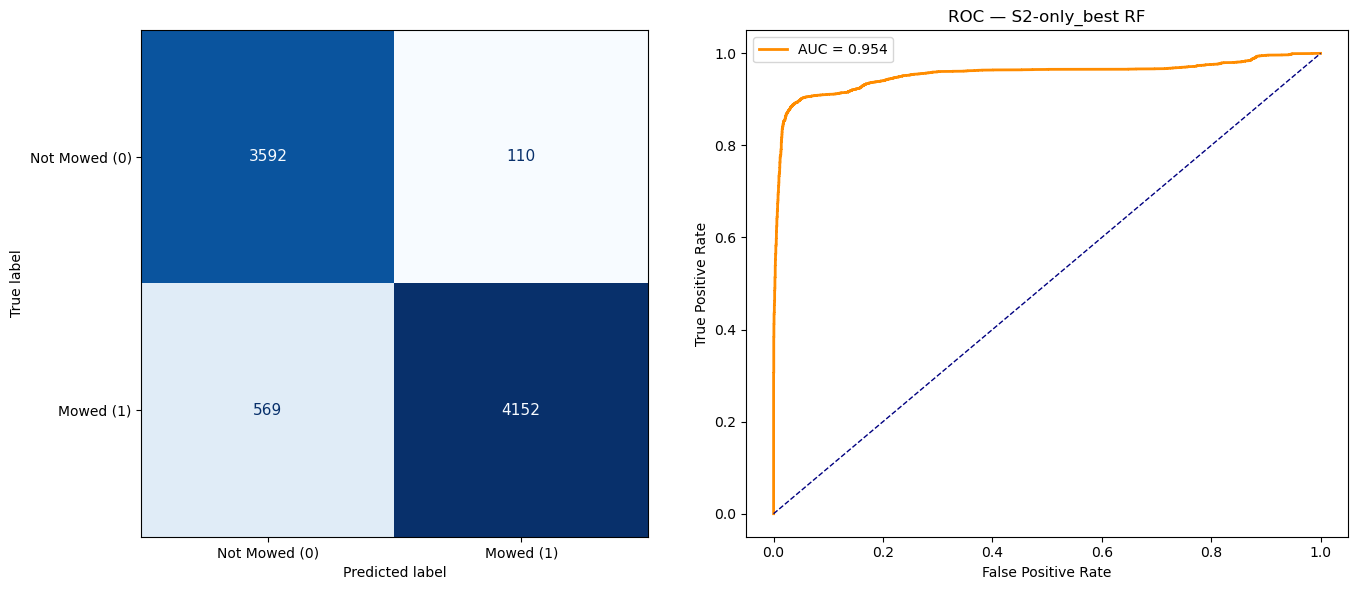

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2-only_best SVM ---
Accuracy: 92.24%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.98      0.92      3702
    Mowed (1)       0.98      0.88      0.93      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



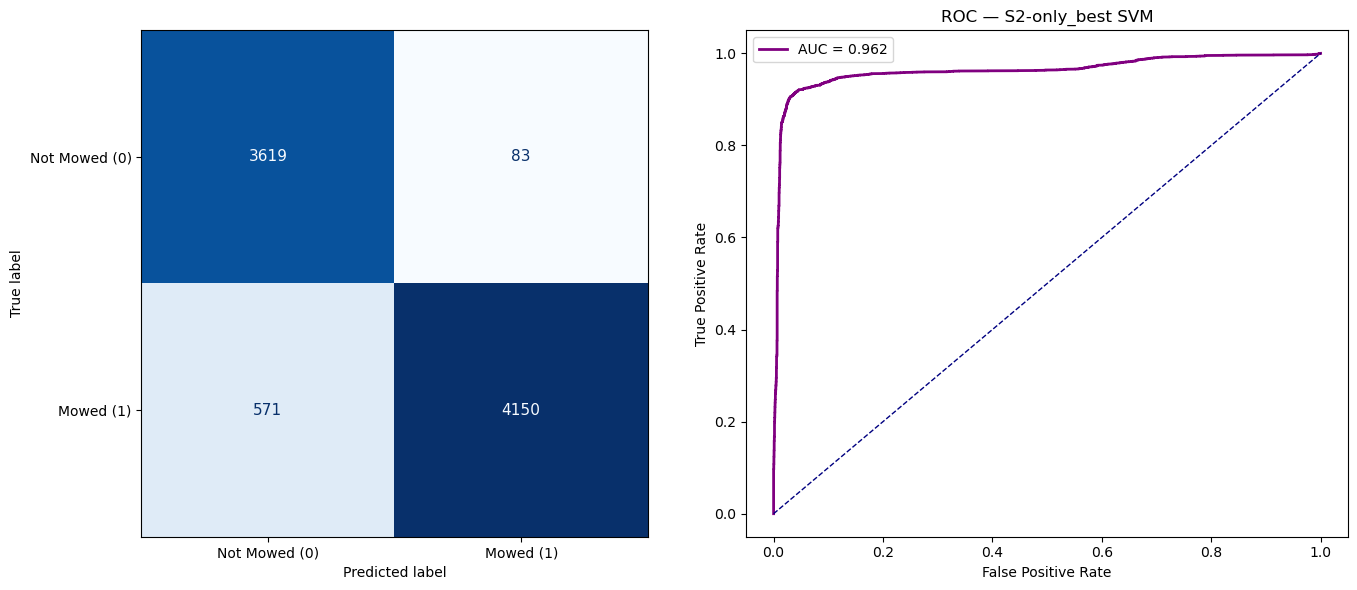

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2-only_best LGBM ---
Accuracy: 91.45%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.96      0.91      3702
    Mowed (1)       0.96      0.88      0.92      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



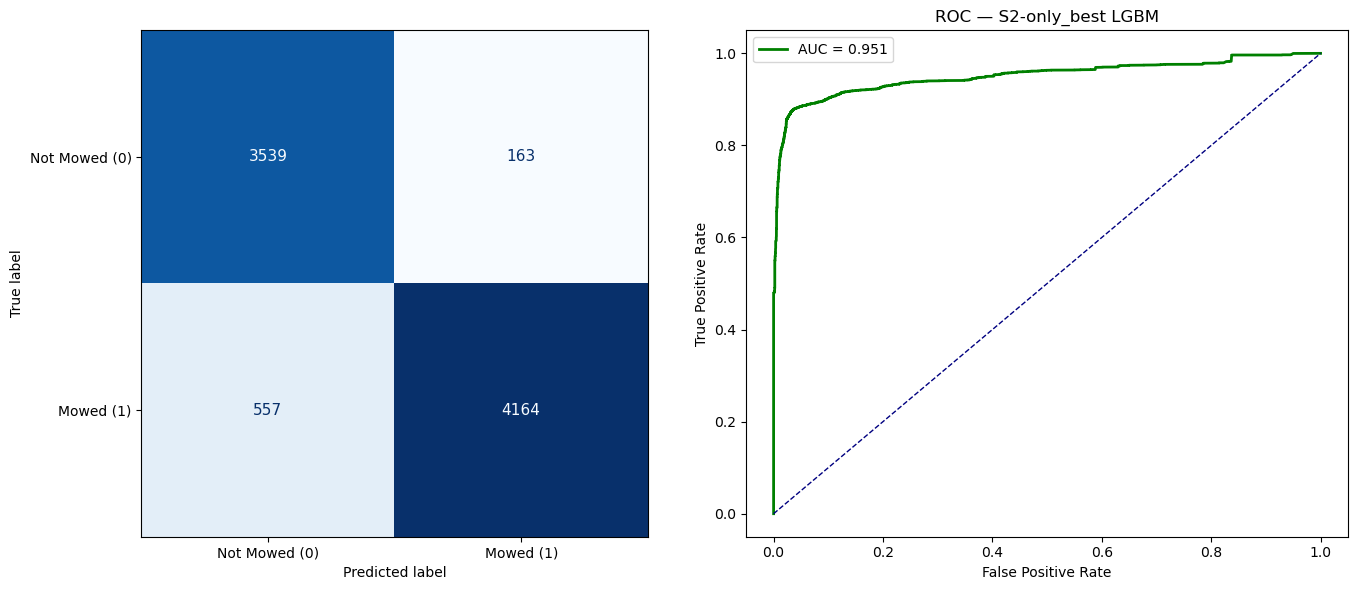

In [49]:
results_A = []

_feats = CONFIGS['S2-only_best']['features']
print(f'=== S2-only_best  ({len(_feats)} features, Group A) ===')
model_s2_only_best_rf = train_tuned_rf(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only_best RF'
)
model_s2_only_best_svm = train_tuned_svm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only_best SVM'
)
model_s2_only_best_lgbm = train_tuned_lgbm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only_best LGBM'
)

=== S2-only_diff  (3 features, Group A) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2-only_diff RF ---
Accuracy: 91.35%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.96      0.91      3702
    Mowed (1)       0.97      0.87      0.92      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



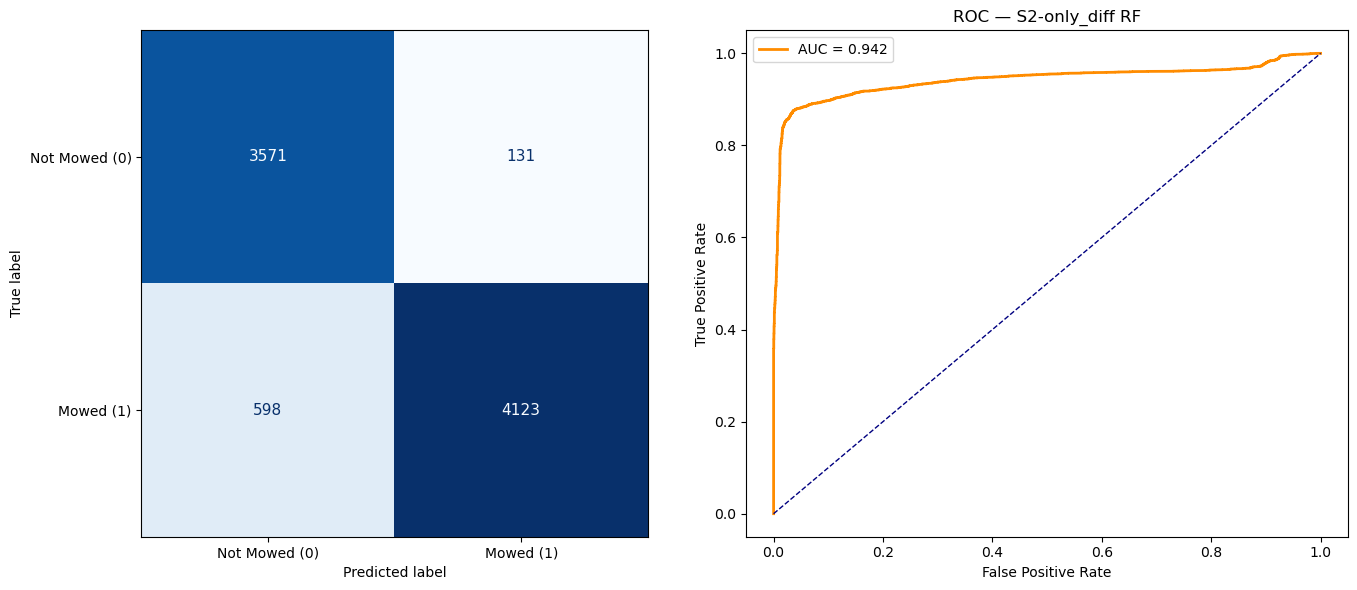

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2-only_diff SVM ---
Accuracy: 91.95%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.98      0.91      3702
    Mowed (1)       0.98      0.87      0.92      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



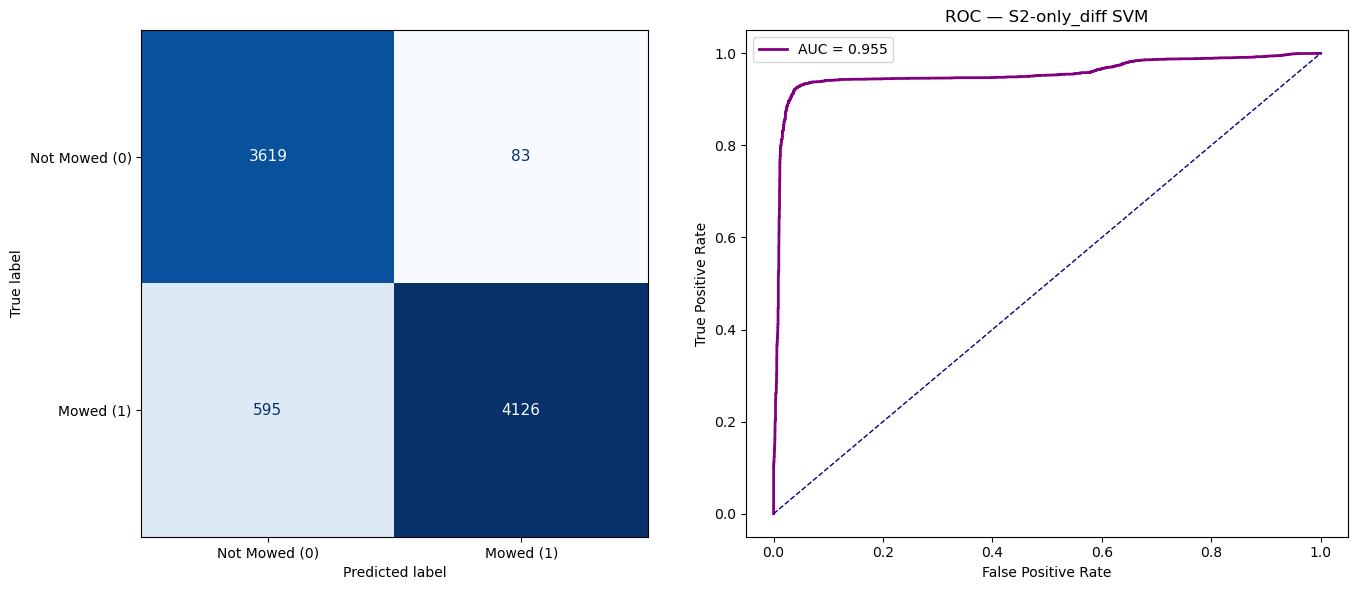

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2-only_diff LGBM ---
Accuracy: 91.00%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.96      0.90      3702
    Mowed (1)       0.97      0.87      0.92      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



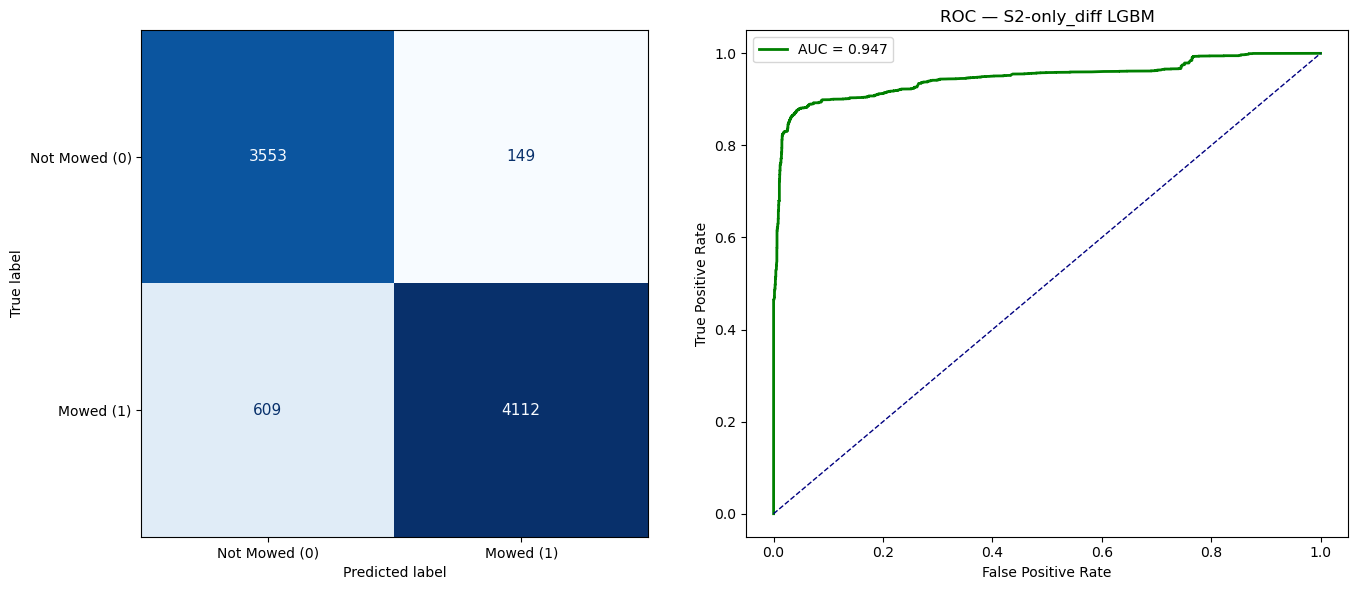

In [50]:
_feats = CONFIGS['S2-only_diff']['features']
print(f'=== S2-only_diff  ({len(_feats)} features, Group A) ===')
model_s2_only_diff_rf = train_tuned_rf(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only_diff RF'
)
model_s2_only_diff_svm = train_tuned_svm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only_diff SVM'
)
model_s2_only_diff_lgbm = train_tuned_lgbm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2-only_diff LGBM'
)

=== GRD-only  (3 features, Group A) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- GRD-only RF ---
Accuracy: 54.32%
               precision    recall  f1-score   support

Not Mowed (0)       0.48      0.42      0.45      3702
    Mowed (1)       0.59      0.64      0.61      4721

     accuracy                           0.54      8423
    macro avg       0.53      0.53      0.53      8423
 weighted avg       0.54      0.54      0.54      8423



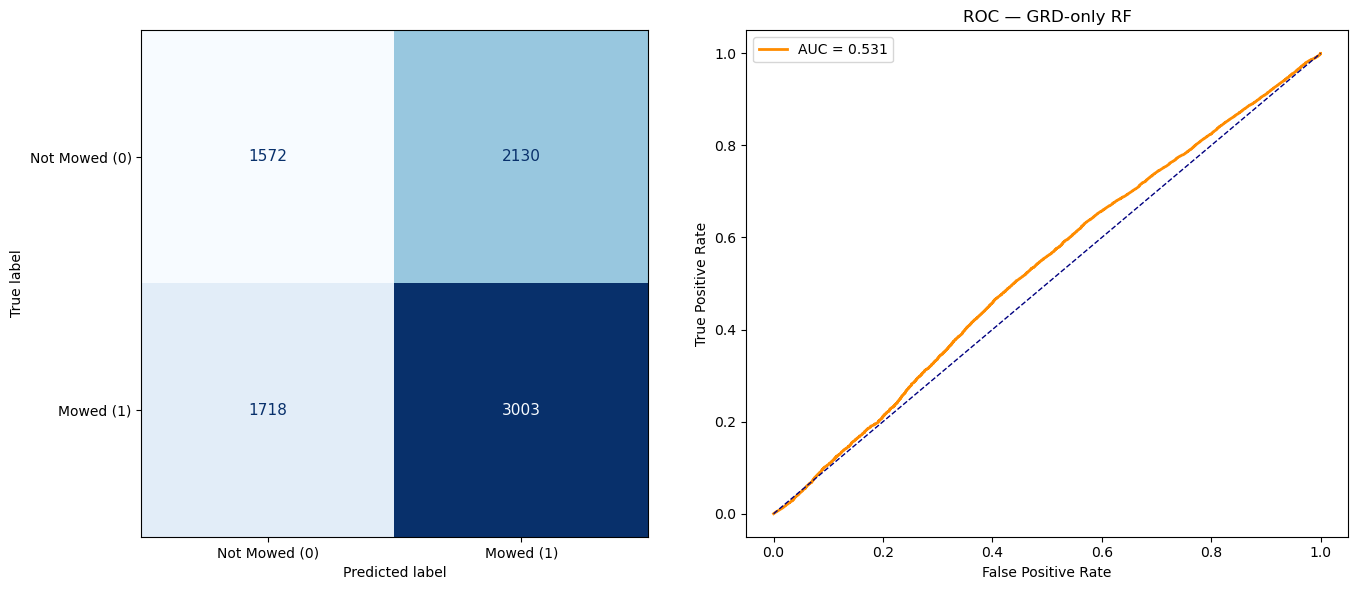

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- GRD-only SVM ---
Accuracy: 55.69%
               precision    recall  f1-score   support

Not Mowed (0)       0.49      0.21      0.29      3702
    Mowed (1)       0.57      0.83      0.68      4721

     accuracy                           0.56      8423
    macro avg       0.53      0.52      0.48      8423
 weighted avg       0.54      0.56      0.51      8423



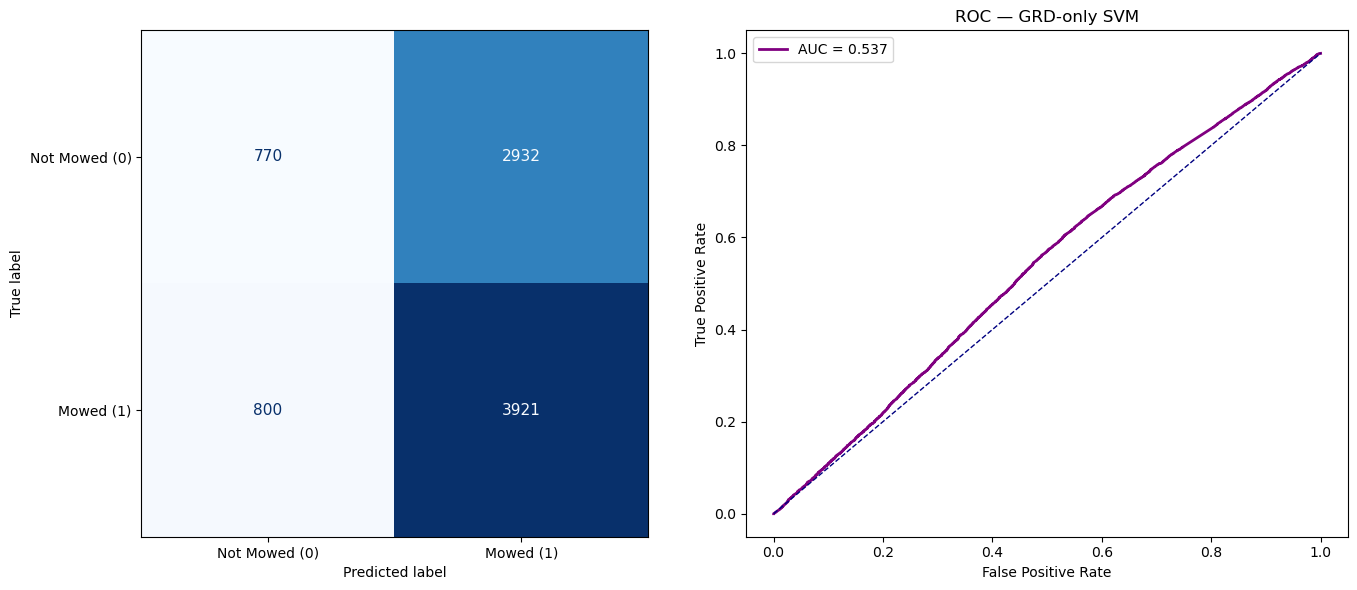

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- GRD-only LGBM ---
Accuracy: 54.09%
               precision    recall  f1-score   support

Not Mowed (0)       0.47      0.38      0.42      3702
    Mowed (1)       0.58      0.67      0.62      4721

     accuracy                           0.54      8423
    macro avg       0.53      0.52      0.52      8423
 weighted avg       0.53      0.54      0.53      8423



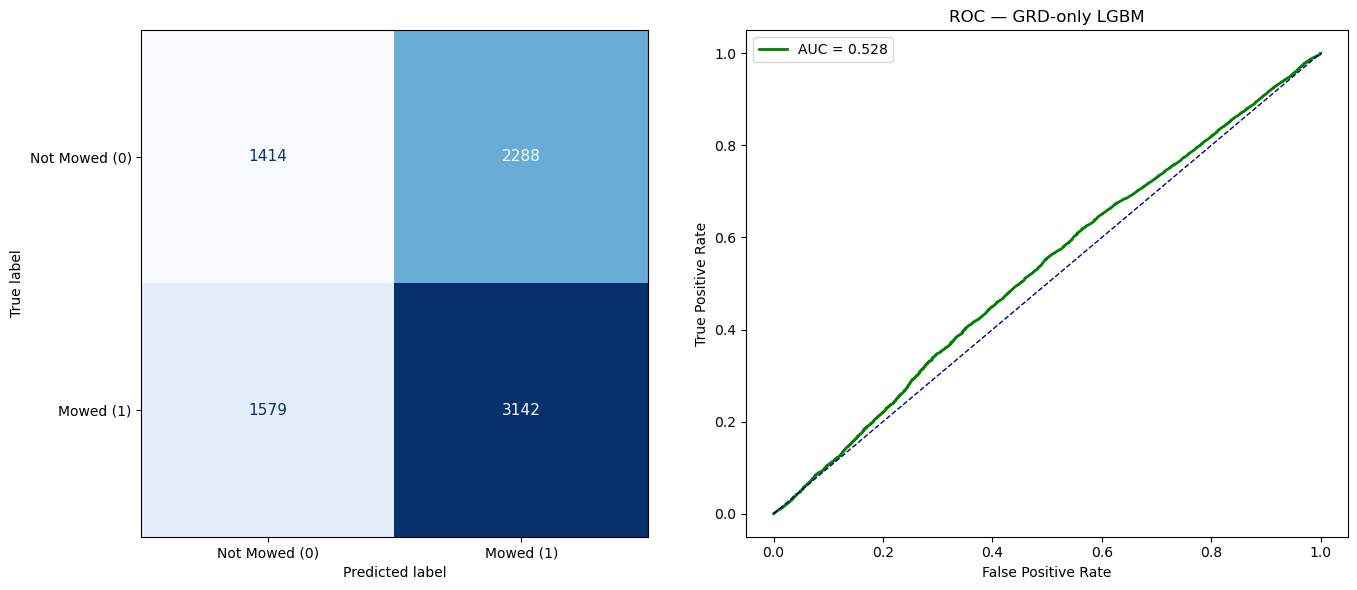

In [51]:
_feats = CONFIGS['GRD-only']['features']
print(f'=== GRD-only  ({len(_feats)} features, Group A) ===')
model_grd_only_rf = train_tuned_rf(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='GRD-only RF'
)
model_grd_only_svm = train_tuned_svm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='GRD-only SVM'
)
model_grd_only_lgbm = train_tuned_lgbm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='GRD-only LGBM'
)

=== S2+GRD  (8 features, Group A) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2+GRD RF ---
Accuracy: 92.00%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.97      0.91      3702
    Mowed (1)       0.98      0.88      0.92      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



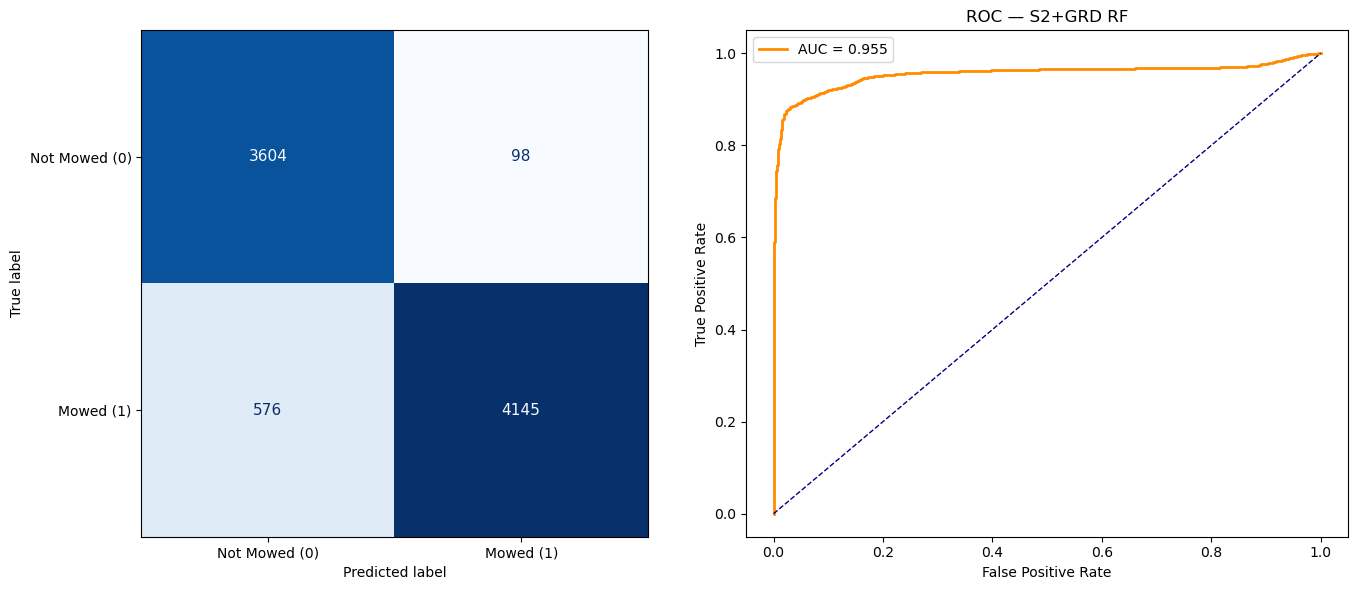

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2+GRD SVM ---
Accuracy: 92.37%
               precision    recall  f1-score   support

Not Mowed (0)       0.87      0.98      0.92      3702
    Mowed (1)       0.98      0.88      0.93      4721

     accuracy                           0.92      8423
    macro avg       0.92      0.93      0.92      8423
 weighted avg       0.93      0.92      0.92      8423



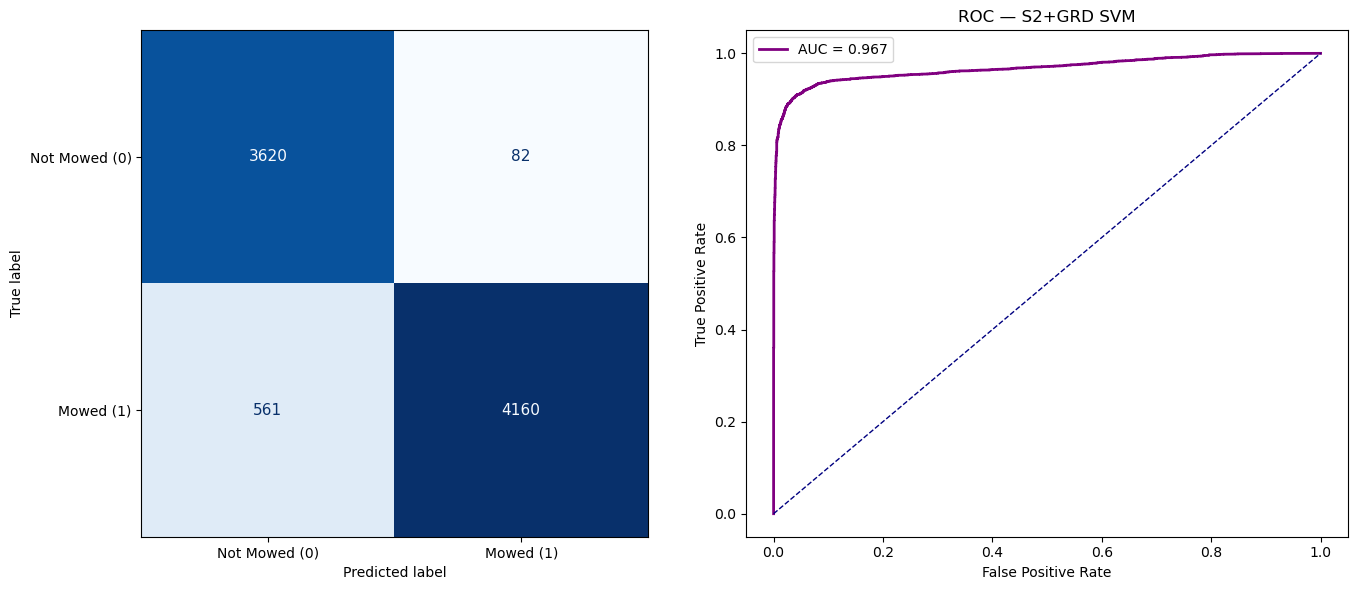

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2+GRD LGBM ---
Accuracy: 91.24%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.95      0.91      3702
    Mowed (1)       0.96      0.88      0.92      4721

     accuracy                           0.91      8423
    macro avg       0.91      0.92      0.91      8423
 weighted avg       0.92      0.91      0.91      8423



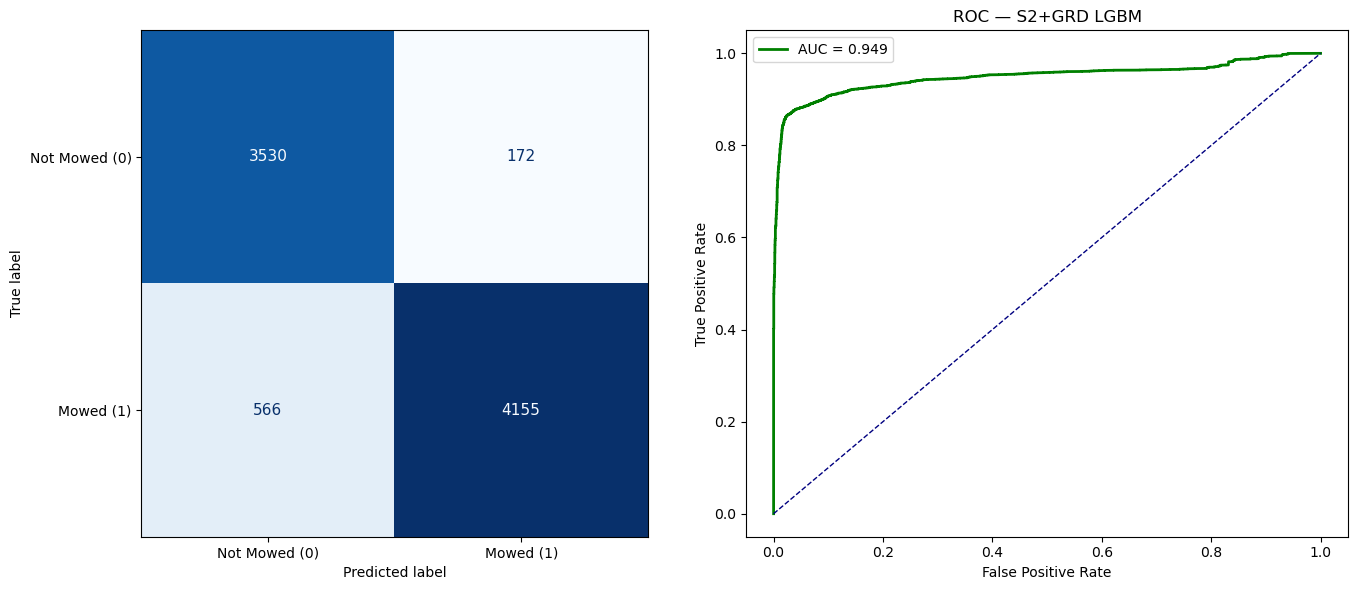

In [52]:
_feats = CONFIGS['S2+GRD']['features']
print(f'=== S2+GRD  ({len(_feats)} features, Group A) ===')
model_s2_grd_rf = train_tuned_rf(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2+GRD RF'
)
model_s2_grd_svm = train_tuned_svm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2+GRD SVM'
)
model_s2_grd_lgbm = train_tuned_lgbm(
    X_train_A[_feats], y_train_A, groups_train_A,
    X_test_A[_feats], y_test_A,
    results_list=results_A, model_alias='S2+GRD LGBM'
)

---
## 4. Group B Training — Coh-only, S2_best+Coh, S2_diff+Coh, Full-fusion

All five configs use the Group B split (`coh_df` — coherence-eligible subset).
Results accumulate in `results_B`.

=== Coh-only  (2 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': None, 'rf__n_estimators': 100}

--- Coh-only RF ---
Accuracy: 47.60%
               precision    recall  f1-score   support

Not Mowed (0)       0.41      0.62      0.49      1340
    Mowed (1)       0.59      0.38      0.46      1948

     accuracy                           0.48      3288
    macro avg       0.50      0.50      0.48      3288
 weighted avg       0.51      0.48      0.47      3288



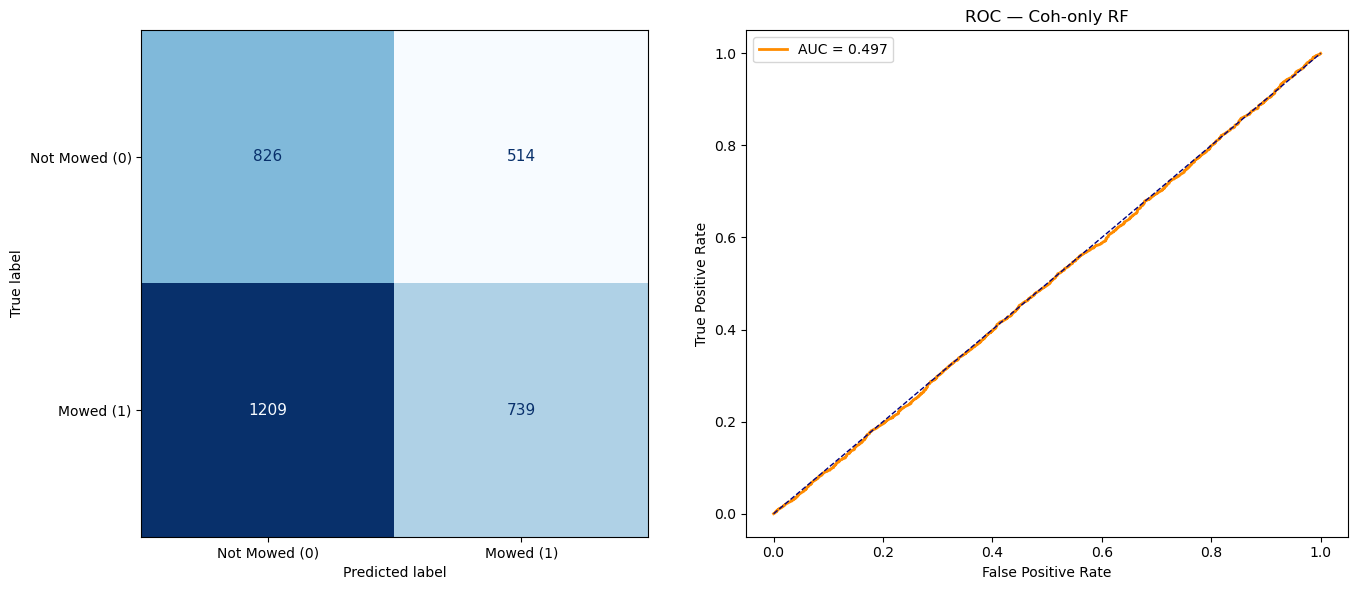

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 10, 'svm__gamma': 'scale'}

--- Coh-only SVM ---
Accuracy: 40.94%
               precision    recall  f1-score   support

Not Mowed (0)       0.41      0.99      0.58      1340
    Mowed (1)       0.58      0.01      0.02      1948

     accuracy                           0.41      3288
    macro avg       0.49      0.50      0.30      3288
 weighted avg       0.51      0.41      0.25      3288



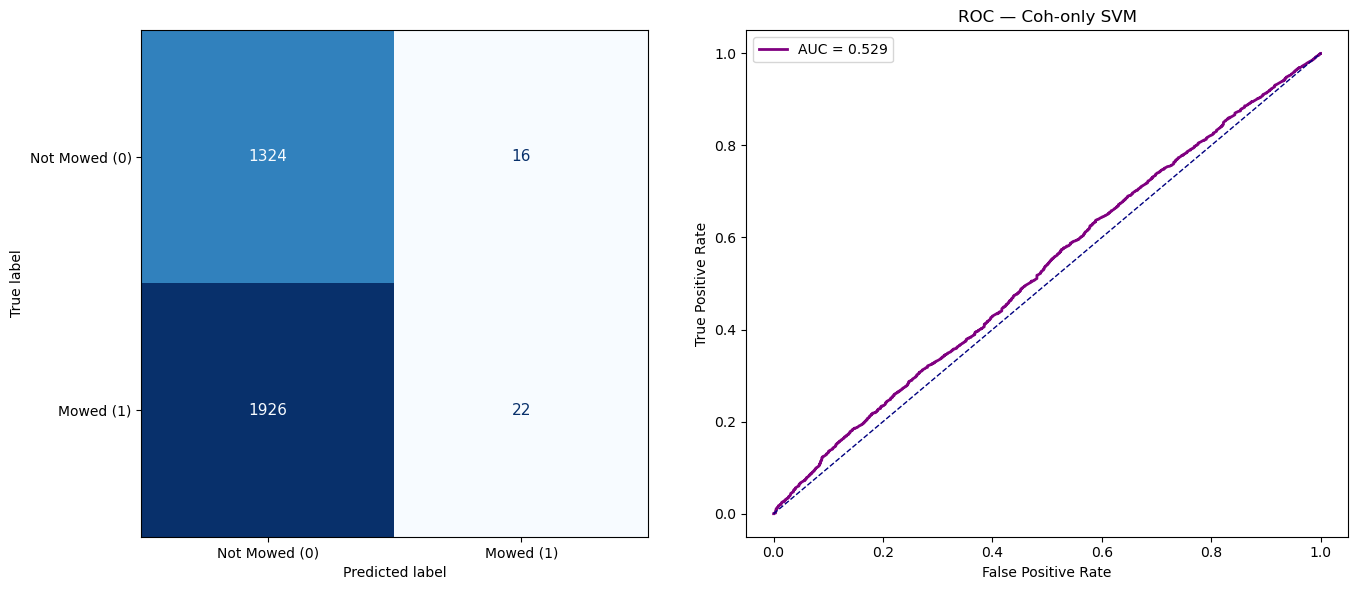

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.1, 'lgbm__num_leaves': 63}

--- Coh-only LGBM ---
Accuracy: 46.32%
               precision    recall  f1-score   support

Not Mowed (0)       0.41      0.69      0.51      1340
    Mowed (1)       0.59      0.30      0.40      1948

     accuracy                           0.46      3288
    macro avg       0.50      0.50      0.46      3288
 weighted avg       0.52      0.46      0.45      3288



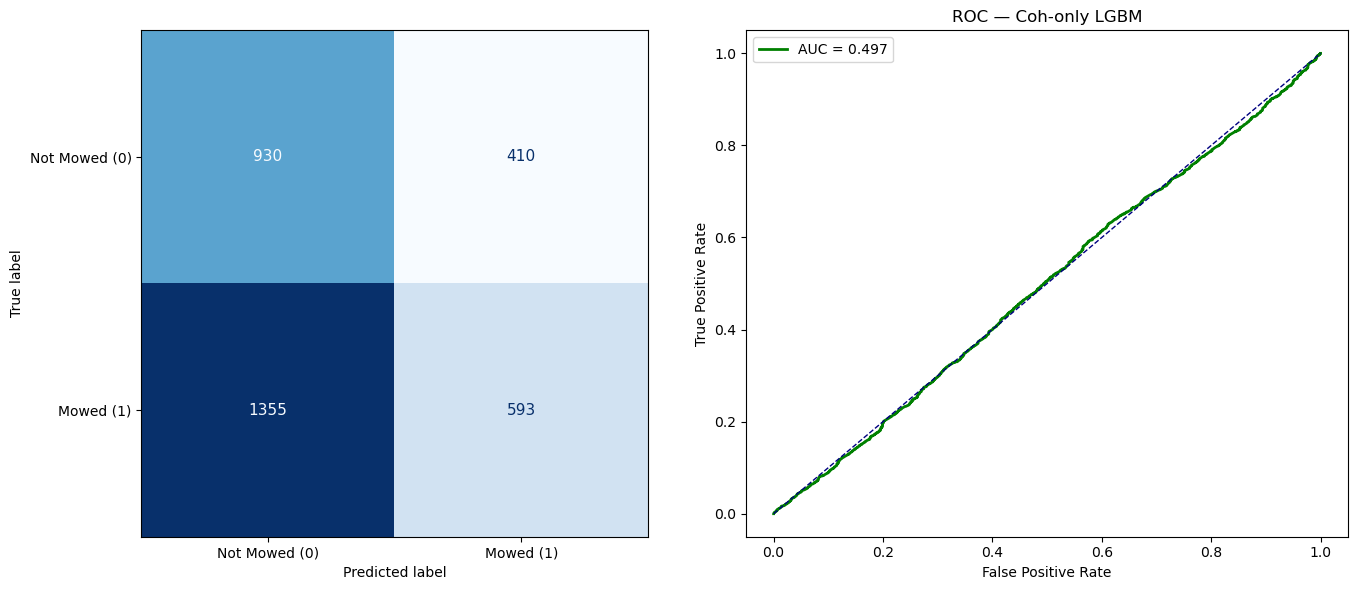

In [53]:
results_B = []

_feats = CONFIGS['Coh-only']['features']
print(f'=== Coh-only  ({len(_feats)} features, Group B) ===')
model_coh_only_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Coh-only RF'
)
model_coh_only_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Coh-only SVM'
)
model_coh_only_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Coh-only LGBM'
)

=== S2_best+Coh  (7 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2_best+Coh RF ---
Accuracy: 91.79%
               precision    recall  f1-score   support

Not Mowed (0)       0.88      0.93      0.90      1340
    Mowed (1)       0.95      0.91      0.93      1948

     accuracy                           0.92      3288
    macro avg       0.91      0.92      0.92      3288
 weighted avg       0.92      0.92      0.92      3288



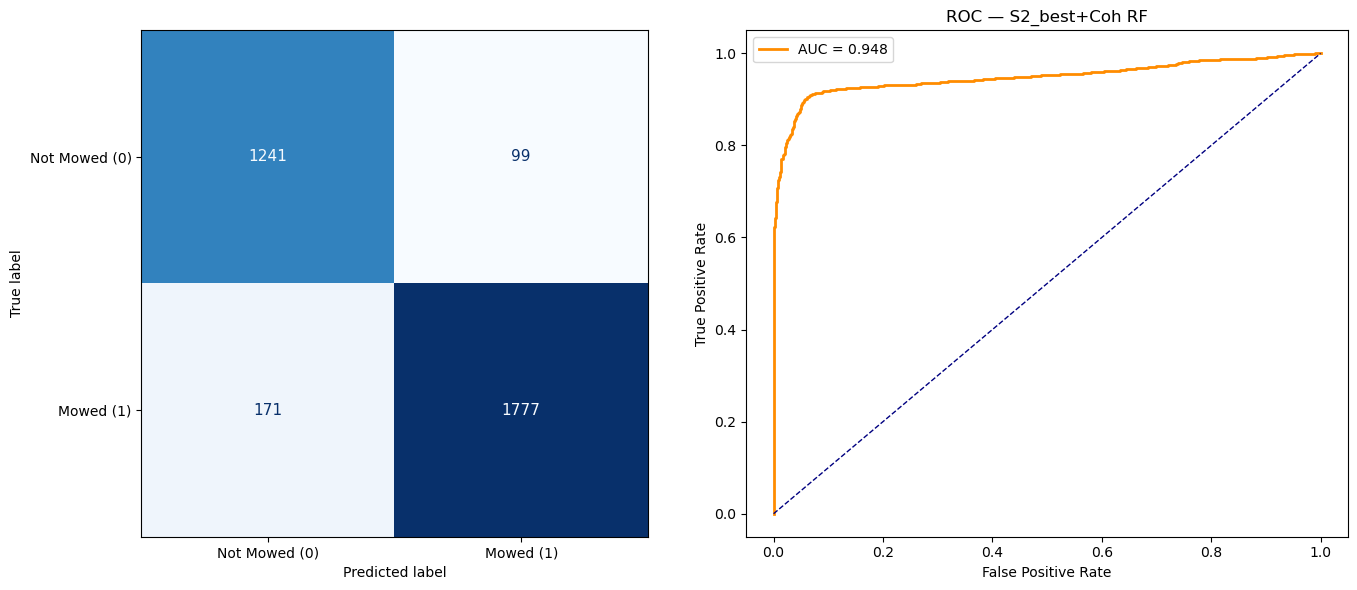

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2_best+Coh SVM ---
Accuracy: 90.66%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.93      0.89      1340
    Mowed (1)       0.95      0.89      0.92      1948

     accuracy                           0.91      3288
    macro avg       0.90      0.91      0.90      3288
 weighted avg       0.91      0.91      0.91      3288



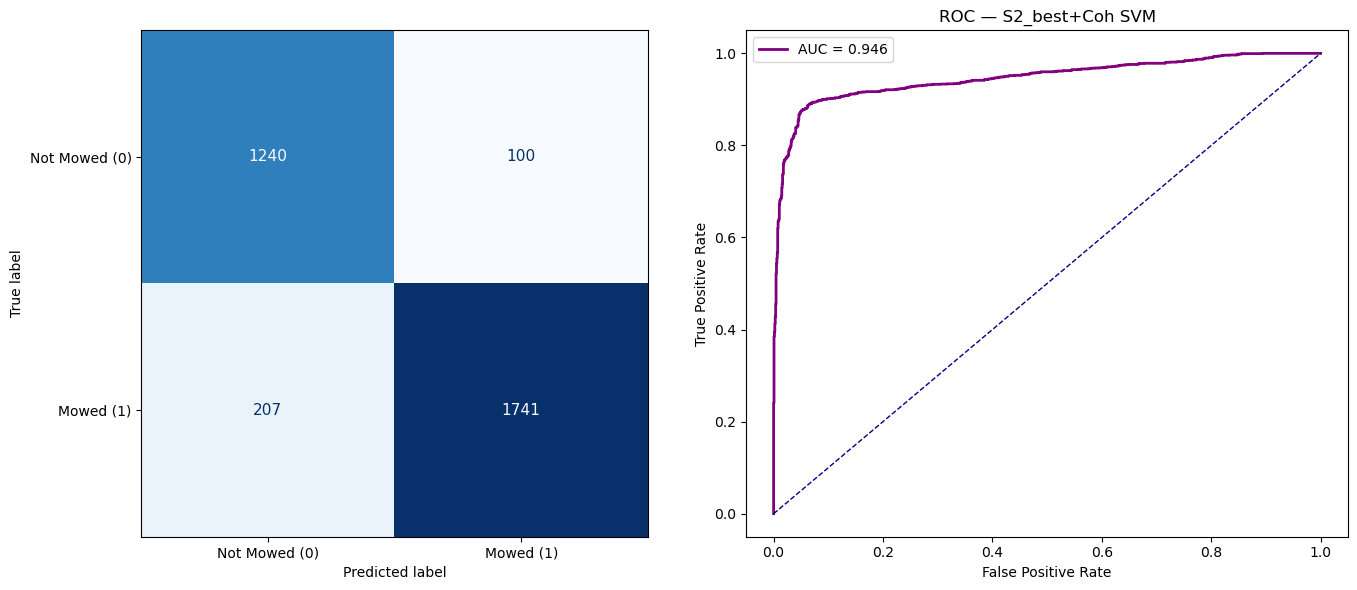

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2_best+Coh LGBM ---
Accuracy: 89.32%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.89      0.87      1340
    Mowed (1)       0.92      0.89      0.91      1948

     accuracy                           0.89      3288
    macro avg       0.89      0.89      0.89      3288
 weighted avg       0.89      0.89      0.89      3288



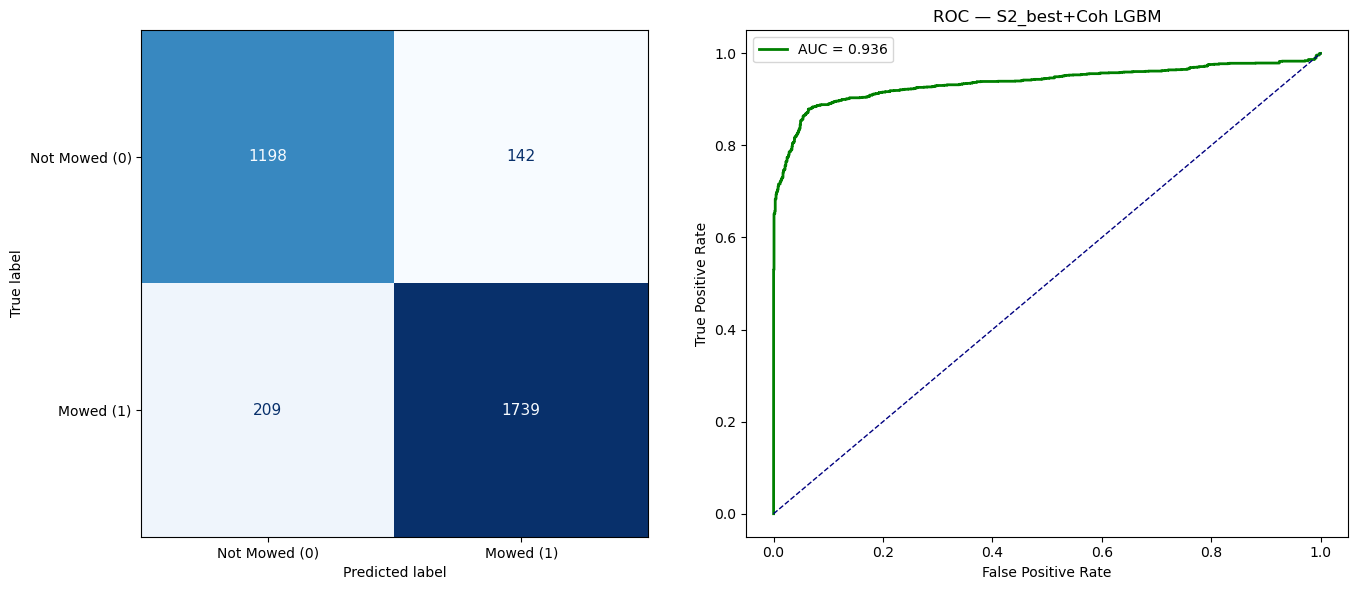

In [54]:
_feats = CONFIGS['S2_best+Coh']['features']
print(f'=== S2_best+Coh  ({len(_feats)} features, Group B) ===')
model_s2_best_coh_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2_best+Coh RF'
)
model_s2_best_coh_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2_best+Coh SVM'
)
model_s2_best_coh_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2_best+Coh LGBM'
)

=== S2_diff+Coh  (5 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- S2_diff+Coh RF ---
Accuracy: 87.35%
               precision    recall  f1-score   support

Not Mowed (0)       0.80      0.92      0.86      1340
    Mowed (1)       0.94      0.84      0.89      1948

     accuracy                           0.87      3288
    macro avg       0.87      0.88      0.87      3288
 weighted avg       0.88      0.87      0.87      3288



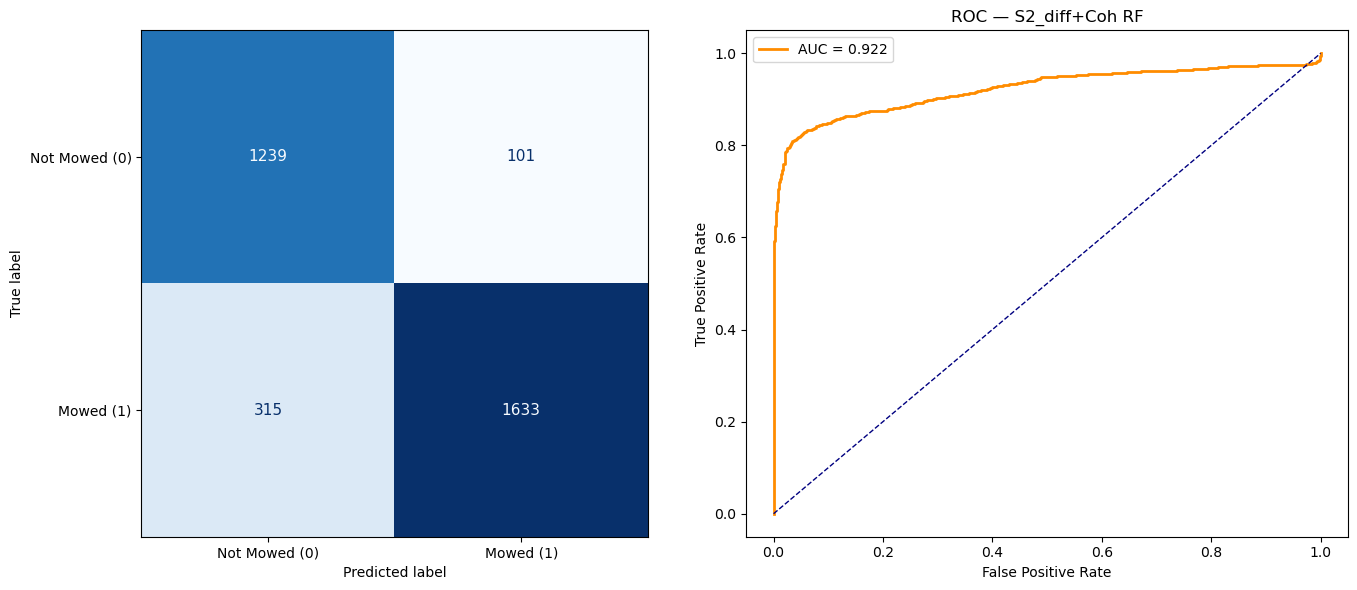

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- S2_diff+Coh SVM ---
Accuracy: 85.01%
               precision    recall  f1-score   support

Not Mowed (0)       0.78      0.88      0.83      1340
    Mowed (1)       0.91      0.83      0.87      1948

     accuracy                           0.85      3288
    macro avg       0.85      0.86      0.85      3288
 weighted avg       0.86      0.85      0.85      3288



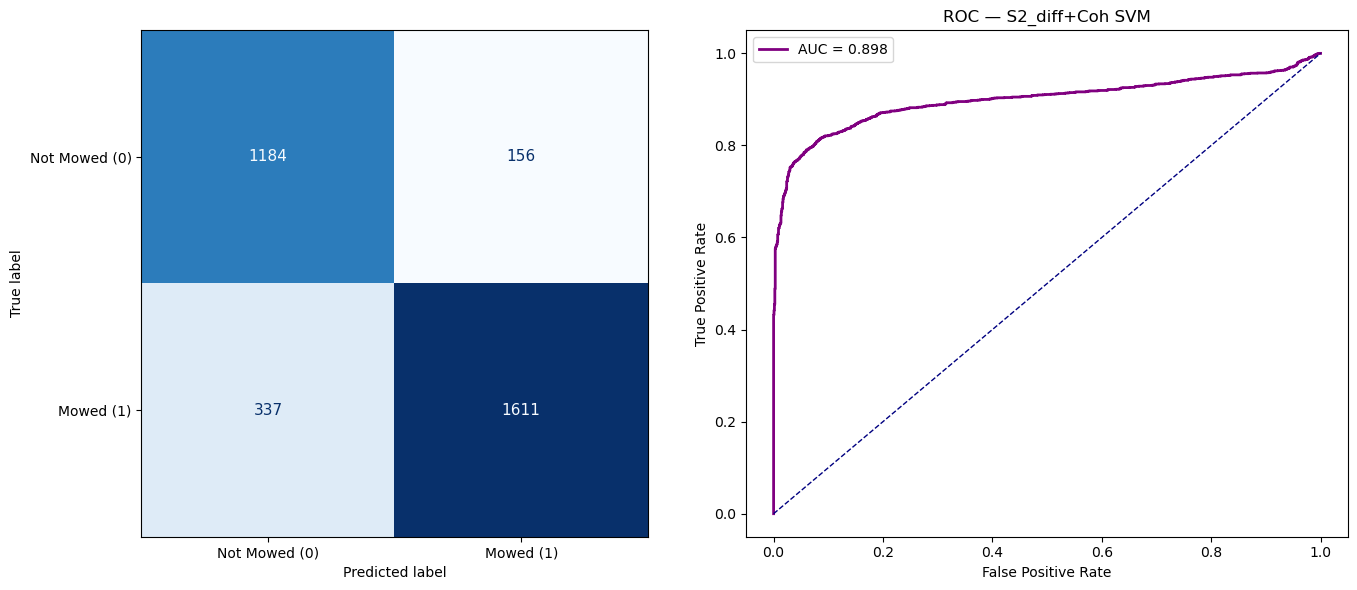

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- S2_diff+Coh LGBM ---
Accuracy: 86.07%
               precision    recall  f1-score   support

Not Mowed (0)       0.78      0.91      0.84      1340
    Mowed (1)       0.93      0.83      0.88      1948

     accuracy                           0.86      3288
    macro avg       0.86      0.87      0.86      3288
 weighted avg       0.87      0.86      0.86      3288



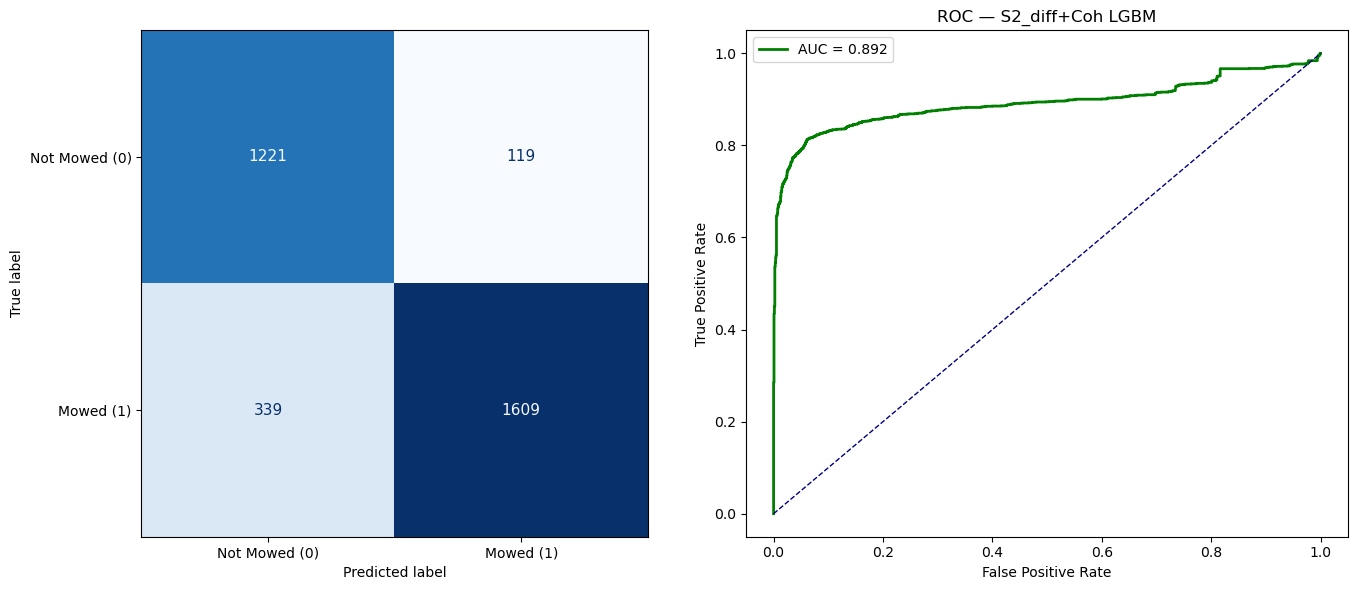

In [55]:
_feats = CONFIGS['S2_diff+Coh']['features']
print(f'=== S2_diff+Coh  ({len(_feats)} features, Group B) ===')
model_s2_diff_coh_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2_diff+Coh RF'
)
model_s2_diff_coh_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2_diff+Coh SVM'
)
model_s2_diff_coh_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='S2_diff+Coh LGBM'
)

=== Full-fusion  (10 features, Group B) ===
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}

--- Full-fusion RF ---
Accuracy: 92.31%
               precision    recall  f1-score   support

Not Mowed (0)       0.88      0.94      0.91      1340
    Mowed (1)       0.95      0.91      0.93      1948

     accuracy                           0.92      3288
    macro avg       0.92      0.93      0.92      3288
 weighted avg       0.92      0.92      0.92      3288



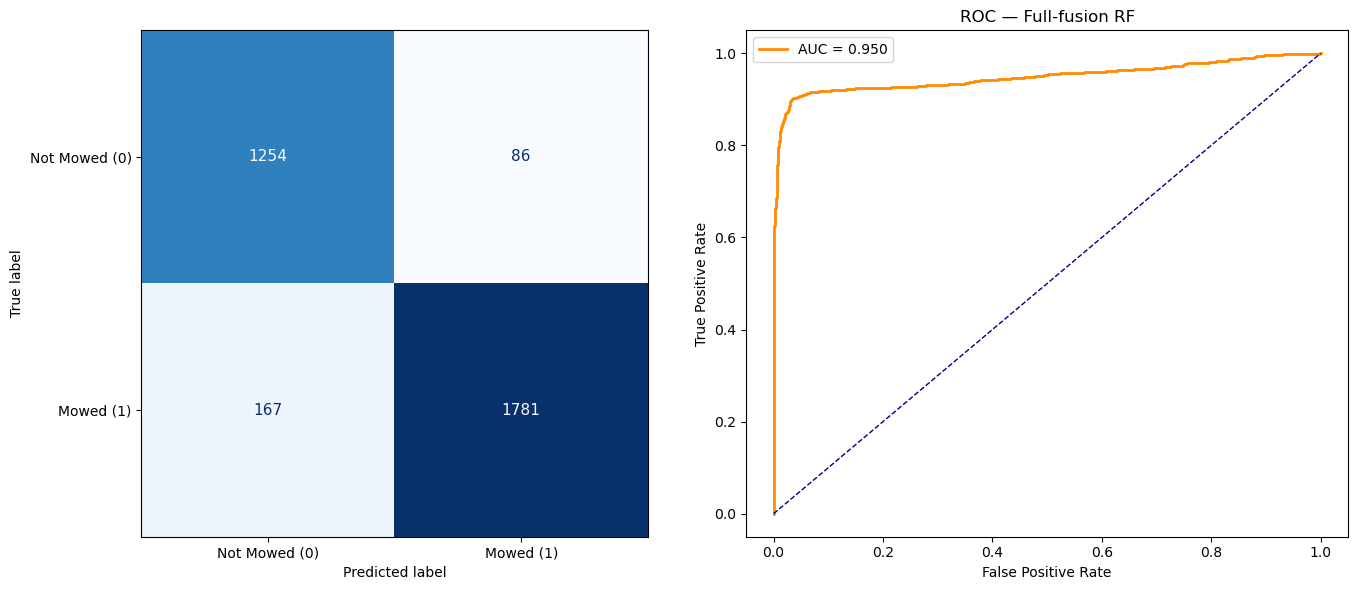

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'svm__C': 0.1, 'svm__gamma': 'scale'}

--- Full-fusion SVM ---
Accuracy: 91.06%
               precision    recall  f1-score   support

Not Mowed (0)       0.86      0.93      0.89      1340
    Mowed (1)       0.95      0.90      0.92      1948

     accuracy                           0.91      3288
    macro avg       0.91      0.91      0.91      3288
 weighted avg       0.91      0.91      0.91      3288



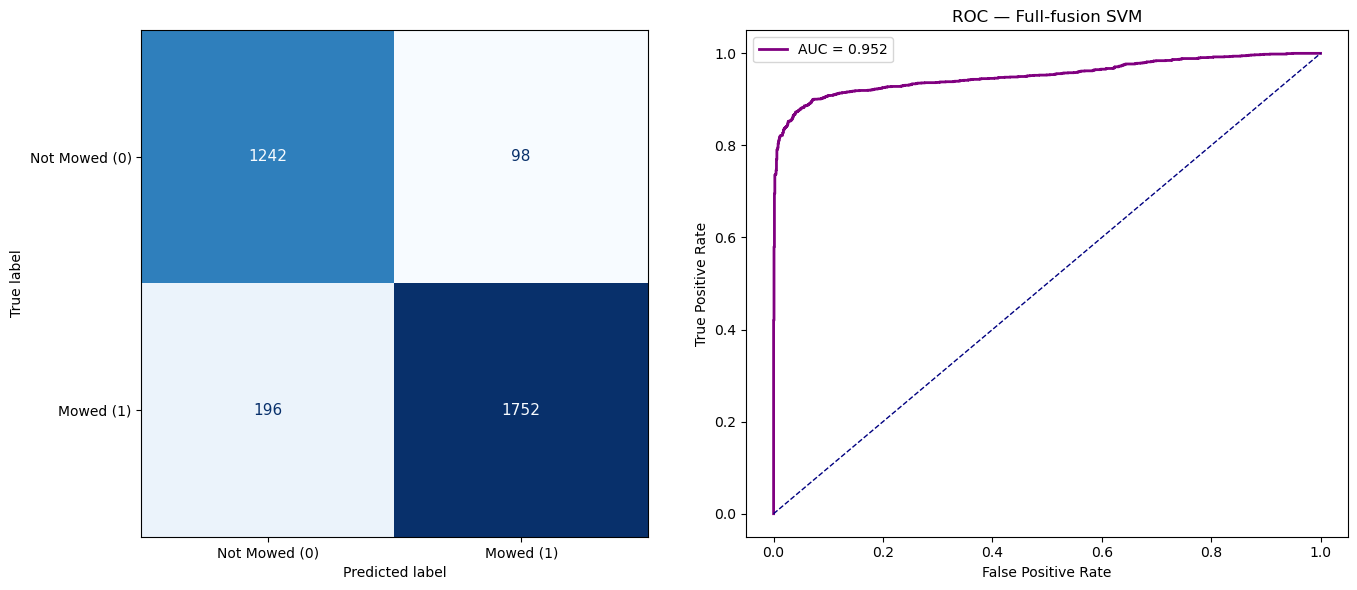

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'lgbm__learning_rate': 0.05, 'lgbm__num_leaves': 31}

--- Full-fusion LGBM ---
Accuracy: 88.53%
               precision    recall  f1-score   support

Not Mowed (0)       0.85      0.88      0.86      1340
    Mowed (1)       0.91      0.89      0.90      1948

     accuracy                           0.89      3288
    macro avg       0.88      0.88      0.88      3288
 weighted avg       0.89      0.89      0.89      3288



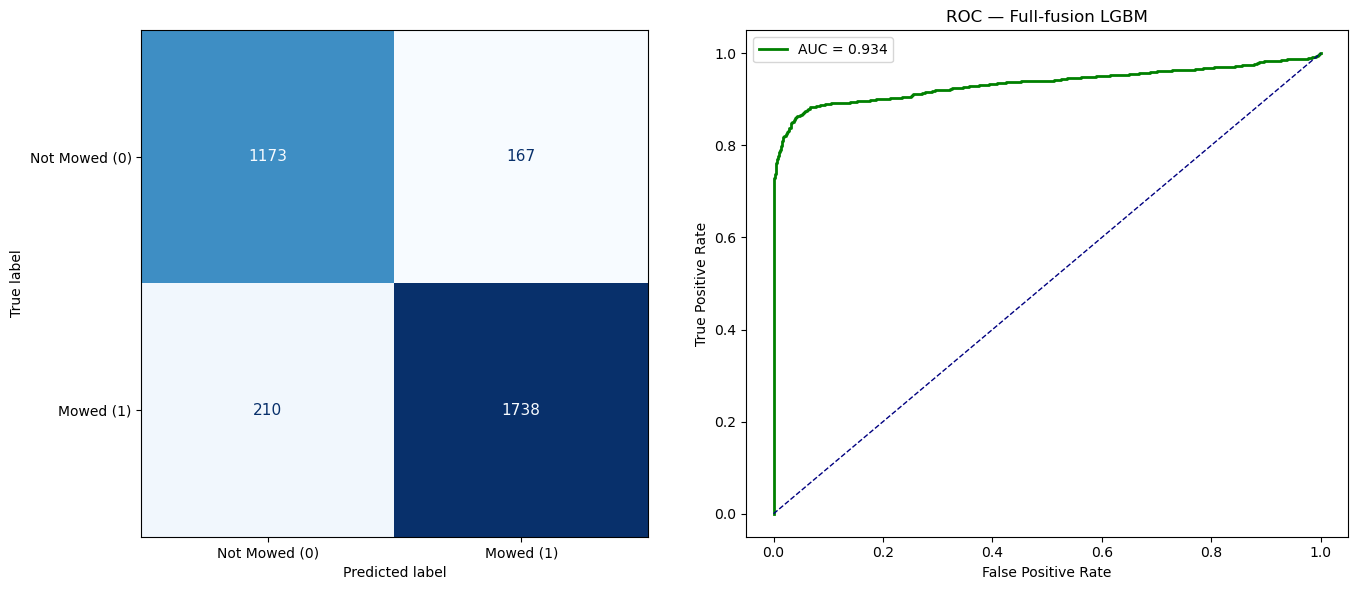

In [56]:
_feats = CONFIGS['Full-fusion']['features']
print(f'=== Full-fusion  ({len(_feats)} features, Group B) ===')
model_full_fusion_rf = train_tuned_rf(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Full-fusion RF'
)
model_full_fusion_svm = train_tuned_svm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Full-fusion SVM'
)
model_full_fusion_lgbm = train_tuned_lgbm(
    X_train_B[_feats], y_train_B, groups_train_B,
    X_test_B[_feats], y_test_B,
    results_list=results_B, model_alias='Full-fusion LGBM'
)

---
## 5. Results Summary and Model Export

In [57]:
# Compile all results and compute optimal thresholds
_model_registry = {
    'S2-only_best RF':     (model_s2_only_best_rf,     'S2-only_best'),
    'S2-only_best SVM':    (model_s2_only_best_svm,    'S2-only_best'),
    'S2-only_best LGBM':   (model_s2_only_best_lgbm,   'S2-only_best'),
    'S2-only_diff RF':     (model_s2_only_diff_rf,     'S2-only_diff'),
    'S2-only_diff SVM':    (model_s2_only_diff_svm,    'S2-only_diff'),
    'S2-only_diff LGBM':   (model_s2_only_diff_lgbm,   'S2-only_diff'),
    'GRD-only RF':         (model_grd_only_rf,         'GRD-only'),
    'GRD-only SVM':        (model_grd_only_svm,        'GRD-only'),
    'GRD-only LGBM':       (model_grd_only_lgbm,       'GRD-only'),
    'S2+GRD RF':           (model_s2_grd_rf,           'S2+GRD'),
    'S2+GRD SVM':          (model_s2_grd_svm,          'S2+GRD'),
    'S2+GRD LGBM':         (model_s2_grd_lgbm,         'S2+GRD'),
    'Coh-only RF':         (model_coh_only_rf,         'Coh-only'),
    'Coh-only SVM':        (model_coh_only_svm,        'Coh-only'),
    'Coh-only LGBM':       (model_coh_only_lgbm,       'Coh-only'),
    'S2_best+Coh RF':      (model_s2_best_coh_rf,      'S2_best+Coh'),
    'S2_best+Coh SVM':     (model_s2_best_coh_svm,     'S2_best+Coh'),
    'S2_best+Coh LGBM':    (model_s2_best_coh_lgbm,    'S2_best+Coh'),
    'S2_diff+Coh RF':      (model_s2_diff_coh_rf,      'S2_diff+Coh'),
    'S2_diff+Coh SVM':     (model_s2_diff_coh_svm,     'S2_diff+Coh'),
    'S2_diff+Coh LGBM':    (model_s2_diff_coh_lgbm,    'S2_diff+Coh'),
    'Full-fusion RF':      (model_full_fusion_rf,      'Full-fusion'),
    'Full-fusion SVM':     (model_full_fusion_svm,     'Full-fusion'),
    'Full-fusion LGBM':    (model_full_fusion_lgbm,    'Full-fusion'),
}

_thresh_rows = []
for alias, (model, cfg_key) in _model_registry.items():
    feats = CONFIGS[cfg_key]['features']
    grp   = CONFIGS[cfg_key]['group']
    X_t   = X_test_A if grp == 'A' else X_test_B
    y_t   = y_test_A if grp == 'A' else y_test_B
    t, _  = find_optimal_threshold(model, X_t[feats], y_t)
    _thresh_rows.append({'Model': alias, 'Threshold': round(t, 4)})

_thresh_df = pd.DataFrame(_thresh_rows)
_all_raw = pd.concat([
    pd.DataFrame(results_A).assign(Group='A'),
    pd.DataFrame(results_B).assign(Group='B'),
], ignore_index=True)
summary_df = _all_raw.merge(_thresh_df, on='Model', how='left')

_print_cols = ['Model', 'Group', 'Num_Features', 'F1_Score', 'Precision', 'Recall', 'Threshold']
print('=== Final Results: 8 Configs × 3 Algorithms (sorted by F1 desc) ===')
print(summary_df[_print_cols]
      .sort_values('F1_Score', ascending=False)
      .reset_index(drop=True)
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== Final Results: 8 Configs × 3 Algorithms (sorted by F1 desc) ===
            Model Group  Num_Features  F1_Score  Precision  Recall  Threshold
       S2+GRD SVM     A             8    0.9239     0.9302  0.9237     0.2947
   Full-fusion RF     B            10    0.9234     0.9248  0.9231     0.6196
 S2-only_best SVM     A             5    0.9226     0.9291  0.9224     0.2585
        S2+GRD RF     A             8    0.9203     0.9265  0.9200     0.4534
 S2-only_diff SVM     A             3    0.9198     0.9269  0.9195     0.3083
  S2-only_best RF     A             5    0.9197     0.9254  0.9194     0.3170
   S2_best+Coh RF     B             7    0.9182     0.9194  0.9179     0.5268
S2-only_best LGBM     A             5    0.9148     0.9191  0.9145     0.5415
  S2-only_diff RF     A             3    0.9138     0.9197  0.9135     0.4402
      S2+GRD LGBM     A             8    0.9127     0.9170  0.9124     0.5309
  Full-fusion SVM     B            10    0.9110     0.9131  0.9106     0.5

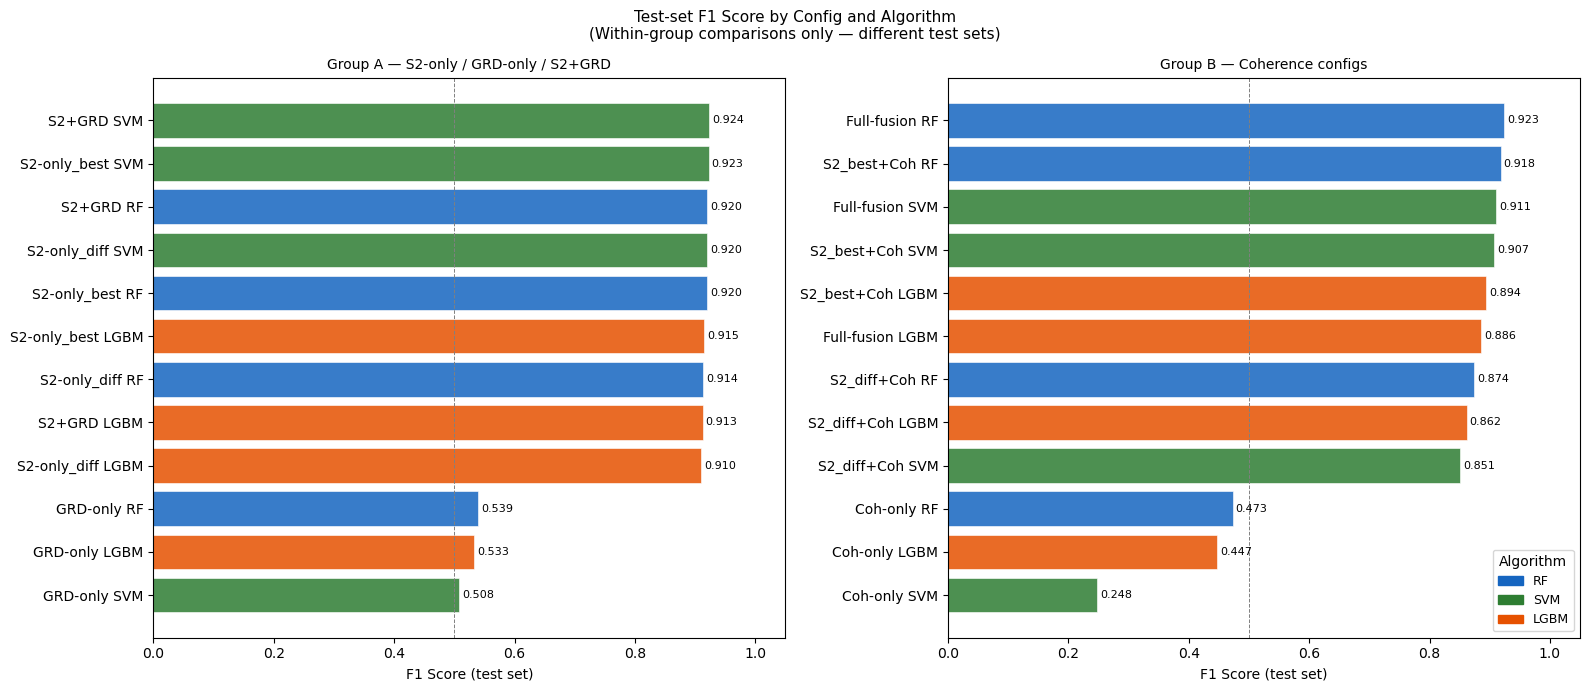

Saved → C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\f1_comparison.png


In [58]:
_algo_color = {'RF': '#1565C0', 'SVM': '#2E7D32', 'LGBM': '#E65100'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, group, title in [
    (axes[0], 'A', 'Group A — S2-only / GRD-only / S2+GRD'),
    (axes[1], 'B', 'Group B — Coherence configs'),
]:
    _g = summary_df[summary_df['Group'] == group].sort_values('F1_Score', ascending=True)
    _colors = [_algo_color[m.split()[-1]] for m in _g['Model']]
    bars = ax.barh(_g['Model'], _g['F1_Score'], color=_colors, alpha=0.85,
                   edgecolor='white', linewidth=0.5)
    ax.set_xlabel('F1 Score (test set)')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1.05)
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.7)
    for bar, val in zip(bars, _g['F1_Score']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

_legend_patches = [
    mpatches.Patch(color=c, label=algo) for algo, c in _algo_color.items()
]
axes[1].legend(handles=_legend_patches, loc='lower right', fontsize=9, title='Algorithm')
plt.suptitle('Test-set F1 Score by Config and Algorithm\n'
             '(Within-group comparisons only — different test sets)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR / "f1_comparison.png"}')

In [ ]:
# Save all 24 models: 8 configs × 3 algorithms
_save_spec = [
    (model_s2_only_best_rf,         'S2-only_best',         's2_only_best_rf.joblib'),
    (model_s2_only_best_svm,        'S2-only_best',         's2_only_best_svm.joblib'),
    (model_s2_only_best_lgbm,       'S2-only_best',         's2_only_best_lgbm.joblib'),
    (model_s2_only_diff_rf,         'S2-only_diff',         's2_only_diff_rf.joblib'),
    (model_s2_only_diff_svm,        'S2-only_diff',         's2_only_diff_svm.joblib'),
    (model_s2_only_diff_lgbm,       'S2-only_diff',         's2_only_diff_lgbm.joblib'),
    (model_grd_only_rf,             'GRD-only',             'grd_only_rf.joblib'),
    (model_grd_only_svm,            'GRD-only',             'grd_only_svm.joblib'),
    (model_grd_only_lgbm,           'GRD-only',             'grd_only_lgbm.joblib'),
    (model_s2_grd_rf,               'S2+GRD',               's2_grd_rf.joblib'),
    (model_s2_grd_svm,              'S2+GRD',               's2_grd_svm.joblib'),
    (model_s2_grd_lgbm,             'S2+GRD',               's2_grd_lgbm.joblib'),
    (model_coh_only_rf,             'Coh-only',             'coh_only_rf.joblib'),
    (model_coh_only_svm,            'Coh-only',             'coh_only_svm.joblib'),
    (model_coh_only_lgbm,           'Coh-only',             'coh_only_lgbm.joblib'),
    (model_s2_best_coh_rf,          'S2_best+Coh',          's2_best_coh_rf.joblib'),
    (model_s2_best_coh_svm,         'S2_best+Coh',          's2_best_coh_svm.joblib'),
    (model_s2_best_coh_lgbm,        'S2_best+Coh',          's2_best_coh_lgbm.joblib'),
    (model_s2_diff_coh_rf,          'S2_diff+Coh',          's2_diff_coh_rf.joblib'),
    (model_s2_diff_coh_svm,         'S2_diff+Coh',          's2_diff_coh_svm.joblib'),
    (model_s2_diff_coh_lgbm,        'S2_diff+Coh',          's2_diff_coh_lgbm.joblib'),
    (model_full_fusion_rf,          'Full-fusion',          'full_fusion_rf.joblib'),
    (model_full_fusion_svm,         'Full-fusion',          'full_fusion_svm.joblib'),
    (model_full_fusion_lgbm,        'Full-fusion',          'full_fusion_lgbm.joblib'),
]

_save_rows = []
for model, cfg_key, fname in _save_spec:
    feats = CONFIGS[cfg_key]['features']
    grp   = CONFIGS[cfg_key]['group']
    X_t   = X_test_A if grp == 'A' else X_test_B
    y_t   = y_test_A if grp == 'A' else y_test_B
    t, f1_opt = find_optimal_threshold(model, X_t[feats], y_t)
    joblib.dump({'model': model, 'features': feats, 'threshold': t},
                os.path.join(MODELS_DIR, fname))
    _save_rows.append({'Config': cfg_key, 'File': fname,
                       'Threshold': round(t, 4), 'F1@opt': round(f1_opt, 4)})

print('=== 24 Models Saved ===')
print(pd.DataFrame(_save_rows).to_string(index=False))
print(f'\nAll artifacts saved to: {MODELS_DIR}')

Removed: s2only_rf.joblib
Removed: s2only_svm.joblib
Removed: s2only_lgbm.joblib
Removed: coh_jumps_only_rf.joblib
Removed: coh_jumps_only_svm.joblib
Removed: coh_jumps_only_lgbm.joblib
Removed: s2_coh_jumps_rf.joblib
Removed: s2_coh_jumps_svm.joblib
Removed: s2_coh_jumps_lgbm.joblib
Removed: s2_coh_rf.joblib
Removed: s2_coh_svm.joblib
Removed: s2_coh_lgbm.joblib
=== 24 Models Saved ===
      Config                     File  Threshold  F1@opt
S2-only_best   s2_only_best_rf.joblib     0.3170  0.9289
S2-only_best  s2_only_best_svm.joblib     0.2585  0.9411
S2-only_best s2_only_best_lgbm.joblib     0.5415  0.9215
S2-only_diff   s2_only_diff_rf.joblib     0.4402  0.9201
S2-only_diff  s2_only_diff_svm.joblib     0.3083  0.9452
S2-only_diff s2_only_diff_lgbm.joblib     0.3771  0.9180
    GRD-only       grd_only_rf.joblib     0.3787  0.7184
    GRD-only      grd_only_svm.joblib     0.4340  0.7186
    GRD-only     grd_only_lgbm.joblib     0.3211  0.7184
      S2+GRD         s2_grd_rf.joblib   